# <center>Laplace Transform Assignment
### <center>Ilamparithi Murali | EEE-B | 107124046
#### <center>Web version of this document (with better continuity) is available at:
#### <center>[https://pseudoforceyt.github.io/projectTitin/ltassignment](https://pseudoforceyt.github.io/projectTitin/ltassignment)
#### <center>Colab notebook is available at:
#### <center>[https://colab.research.google.com/github/pseudoforceyt/projectTitin/blob/main/ltassignment.ipynb](https://colab.research.google.com/github/pseudoforceyt/projectTitin/blob/main/ltassignment.ipynb)

## Functions involved in the assignment

#### Heaviside Unit Step Function $[u(0) = 1\ \text{convention}]$


$$
u_{a}(t) = u(t-a) =
\begin{cases}
0, & t < a \\
1, & t \geq a
\end{cases}
$$



#### Dirac Delta Function (Unit Impulse Function)



$$
\delta_{a}(t) = \delta(t-a) = \lim_{h \to 0} f(t) \
$$
where $f(t)$ is defined as:
$$
f(t) =
\begin{cases}
\frac{1}{h}, & a - \frac{h}{2} \leq t \leq a + \frac{h}{2} \\
0, & otherwise
\end{cases}
$$



#### Periodic Function



A function $f(t)$ is called periodic if there exists a positive number $T$ such that:

$$
f(t + T) = f(t) \quad \text{for all } t
$$

The smallest such $T$ is called the **fundamental period**.

## Initial Setup for Plot Formatting

We will be using the Python library `Matplotlib` to visualise our plots. To match the formatting of the rest of the document, we will edit the `rcParams`:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    # Font Configuration, Commented out because Colab won't have CMU Serif installed
    # "font.family": "CMU Serif",
    # "mathtext.fontset": "custom",
    # "mathtext.rm": "CMU Serif",
    # "mathtext.it": "CMU Serif:italic",
    # "mathtext.bf": "CMU Serif:bold",
    # "mathtext.cal": "CMU Serif:italic",
    # "mathtext.sf": "CMU Serif:italic",
    # "mathtext.default": "it",
    # "axes.unicode_minus": False,          # CMU Serif does not support minus sign
    # Size Configuration
    "font.size": 32,                      # Main font size
    "axes.titlesize": 36,                 # Title of the plot
    "axes.labelsize": 32,                 # x and y labels
    "xtick.labelsize": 28,                # x tick labels
    "ytick.labelsize": 28,                # y tick labels
    "legend.fontsize": 32,                # Legend font size
    "figure.titlesize": 40                # Figure title (if used)
})


## Part - A: Real Life Scenarios and Conceptual Fun



### 1. Time Travel with the Unit Step Function



We aim to design a teleportation device that turns ON at $t = 3s$ and OFF at $t = 7s$. If we consider the value $0$ as OFF and $1$ as ON, we can represent it as the function:

$$
f(t) =
\begin{cases}
0, & t < 3\ or\ t \geq 7s\\
1, & t \geq 0
\end{cases}
$$

On observation, this function takes the value $1$ only in a finite interval. We can utilise the **Heaviside Unit Step Function** to represent this mathematically:

$$f(t)=u(t-3) - u(t-7)$$

Finding the Laplace Transform of this function:

$$
\mathcal{L}\{f(t)\} = \mathcal{L}\{u(t-3) - u(t-7)\}
= \mathcal{L}\{u(t-3)\} - \mathcal{L}\{u(t-7)\}\ \text{(Linearity Property)}
$$

Laplace Transform of Heaviside Unit Step Function:

$$
\begin{aligned}
\mathcal{L}\{u(t - a)\} &= \int_0^\infty u(t - a) \cdot e^{-st} \, dt \\
&= \int_0^a 0 \cdot e^{-st} \, dt + \int_a^\infty 1 \cdot e^{-st} \, dt \\
&= \int_a^\infty e^{-st} \, dt \\
&= \left[ \frac{e^{-st}}{-s} \right]_a^\infty \\
&= 0 - \left( \frac{e^{-as}}{-s} \right) \\
&= \frac{e^{-as}}{s}
\end{aligned}
$$

Going back to our function,

$$
\mathcal{L}\{f(t)\} = \mathcal{L}\{u(t-3)\} - \mathcal{L}\{u(t-7)\}\ \\
\\[1em]
\boxed{\mathcal{L}\{f(t)\} = \frac{e^{-3s}}{s} - \frac{e^{-7s}}{s}}
$$



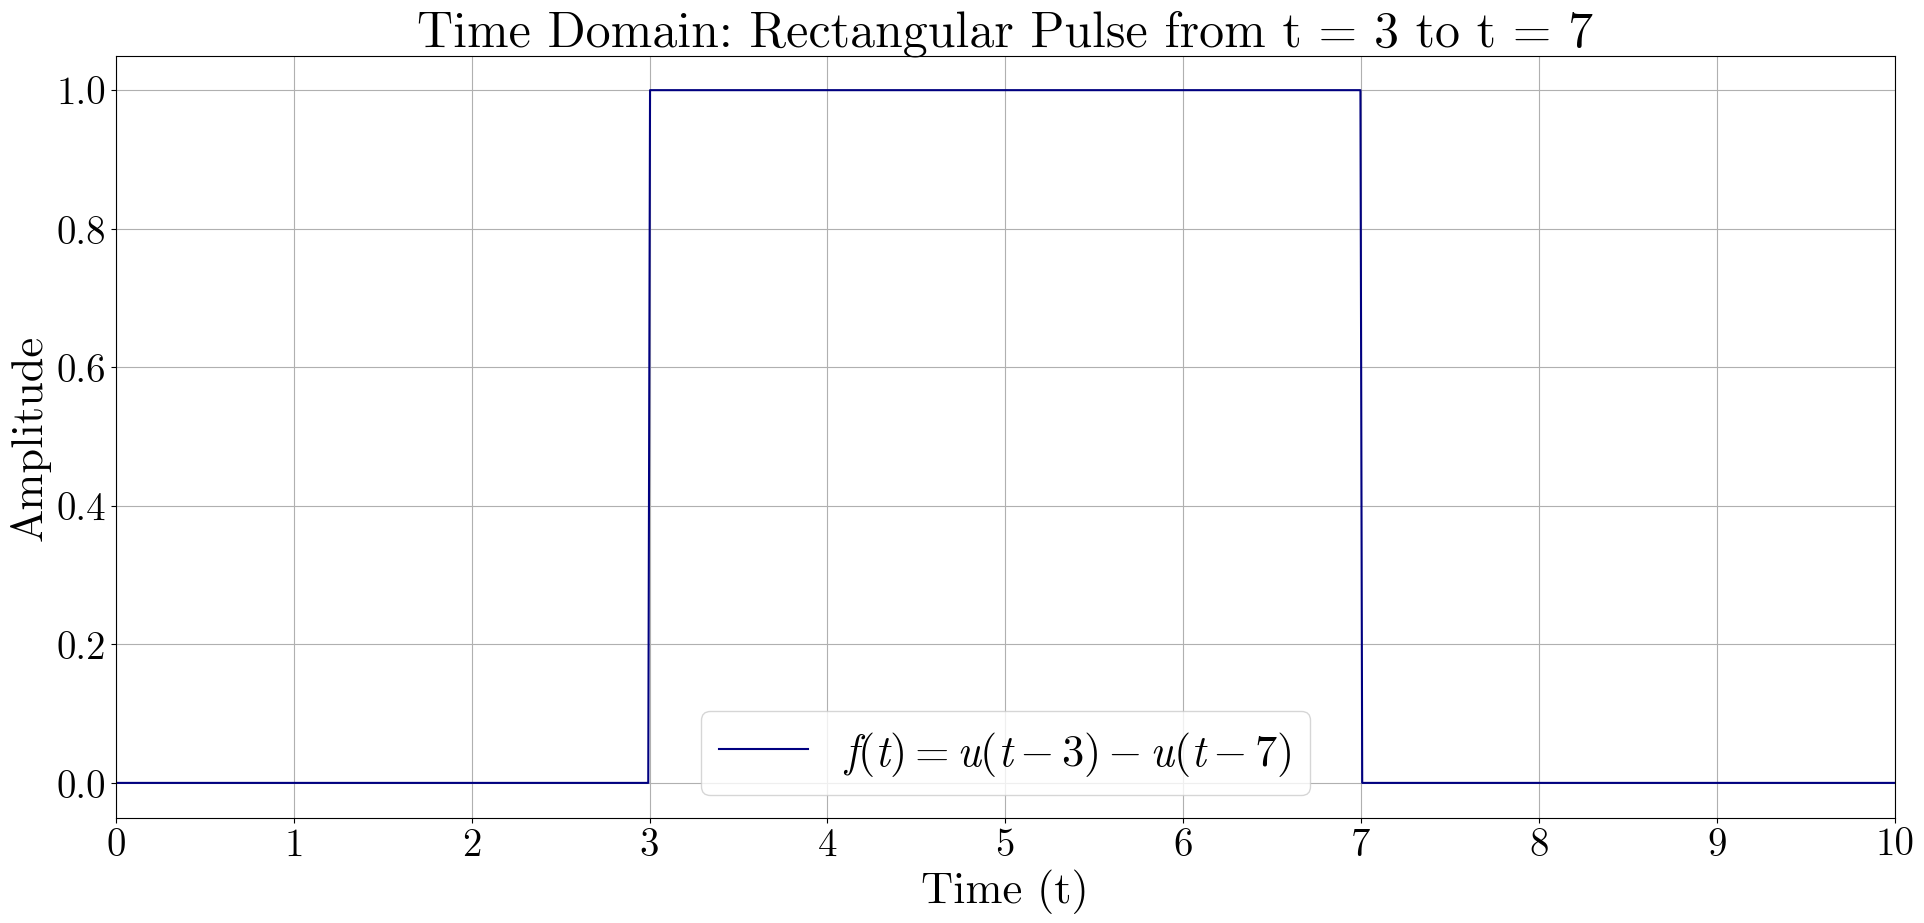

In [ ]:
# Define time values
t = np.linspace(0, 10, 1000)

# Define the rectangular pulse: f(t) = u(t-3) - u(t-7)
f_t = np.where((t >= 3) & (t < 7), 1, 0)

# Plot the time-domain signal
plt.figure(figsize=(20, 10))
plt.plot(t, f_t, label=r'$f(t) = u(t-3) - u(t-7)$', color='navy')
plt.title("Time Domain: Rectangular Pulse from t = 3 to t = 7")
plt.xlabel("Time (t)")
plt.ylabel("Amplitude")
plt.xticks(np.arange(0, 11, 1))
plt.xlim(0, 10)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


The Laplace transform we just obtained can we interpreted this way: The $1/s$ is the Laplace Transform of the Heaviside Unit Step Function. The $e^{-3s}$ and $e^{-7s}$ arise from the shifting of the ON signal from $t=0$ to $t=3\ \&\ 7$ respectively, with the **Second Shifting Theorem (Frequency Shifting)** $(\mathcal{L}\{f(t - a) \cdot u(t - a)\} = e^{-as} \cdot \mathcal{L}\{f(t)\})$

Taking $e^{-3t}$ common in the final expression, we get:

$$
\mathcal{L}\{f(t)\} = e^{-3s}\frac{(1 - e^{-4s})}{s}
$$

The 3 in $e^{-3s}$ suggests that there is a **delay of 3 seconds** in the signal. The 4 in the $(1-e^{-4s})$ suggests that the **signal width is 4 seconds**, ie., the pulse is observed for 4 seconds.

We replace $s$ with $j\omega$ (where $\omega$ is the frequency in $rad/s$):

$$
F(j\omega) = e^{-3j\omega}\frac{(1 - e^{-4j\omega})}{j\omega}
$$

This is the **Fourier Transform** of our function. To plot this on the amplitude vs. frequency graph, we have to get the amplitude. This can be handled using `NumPy`:

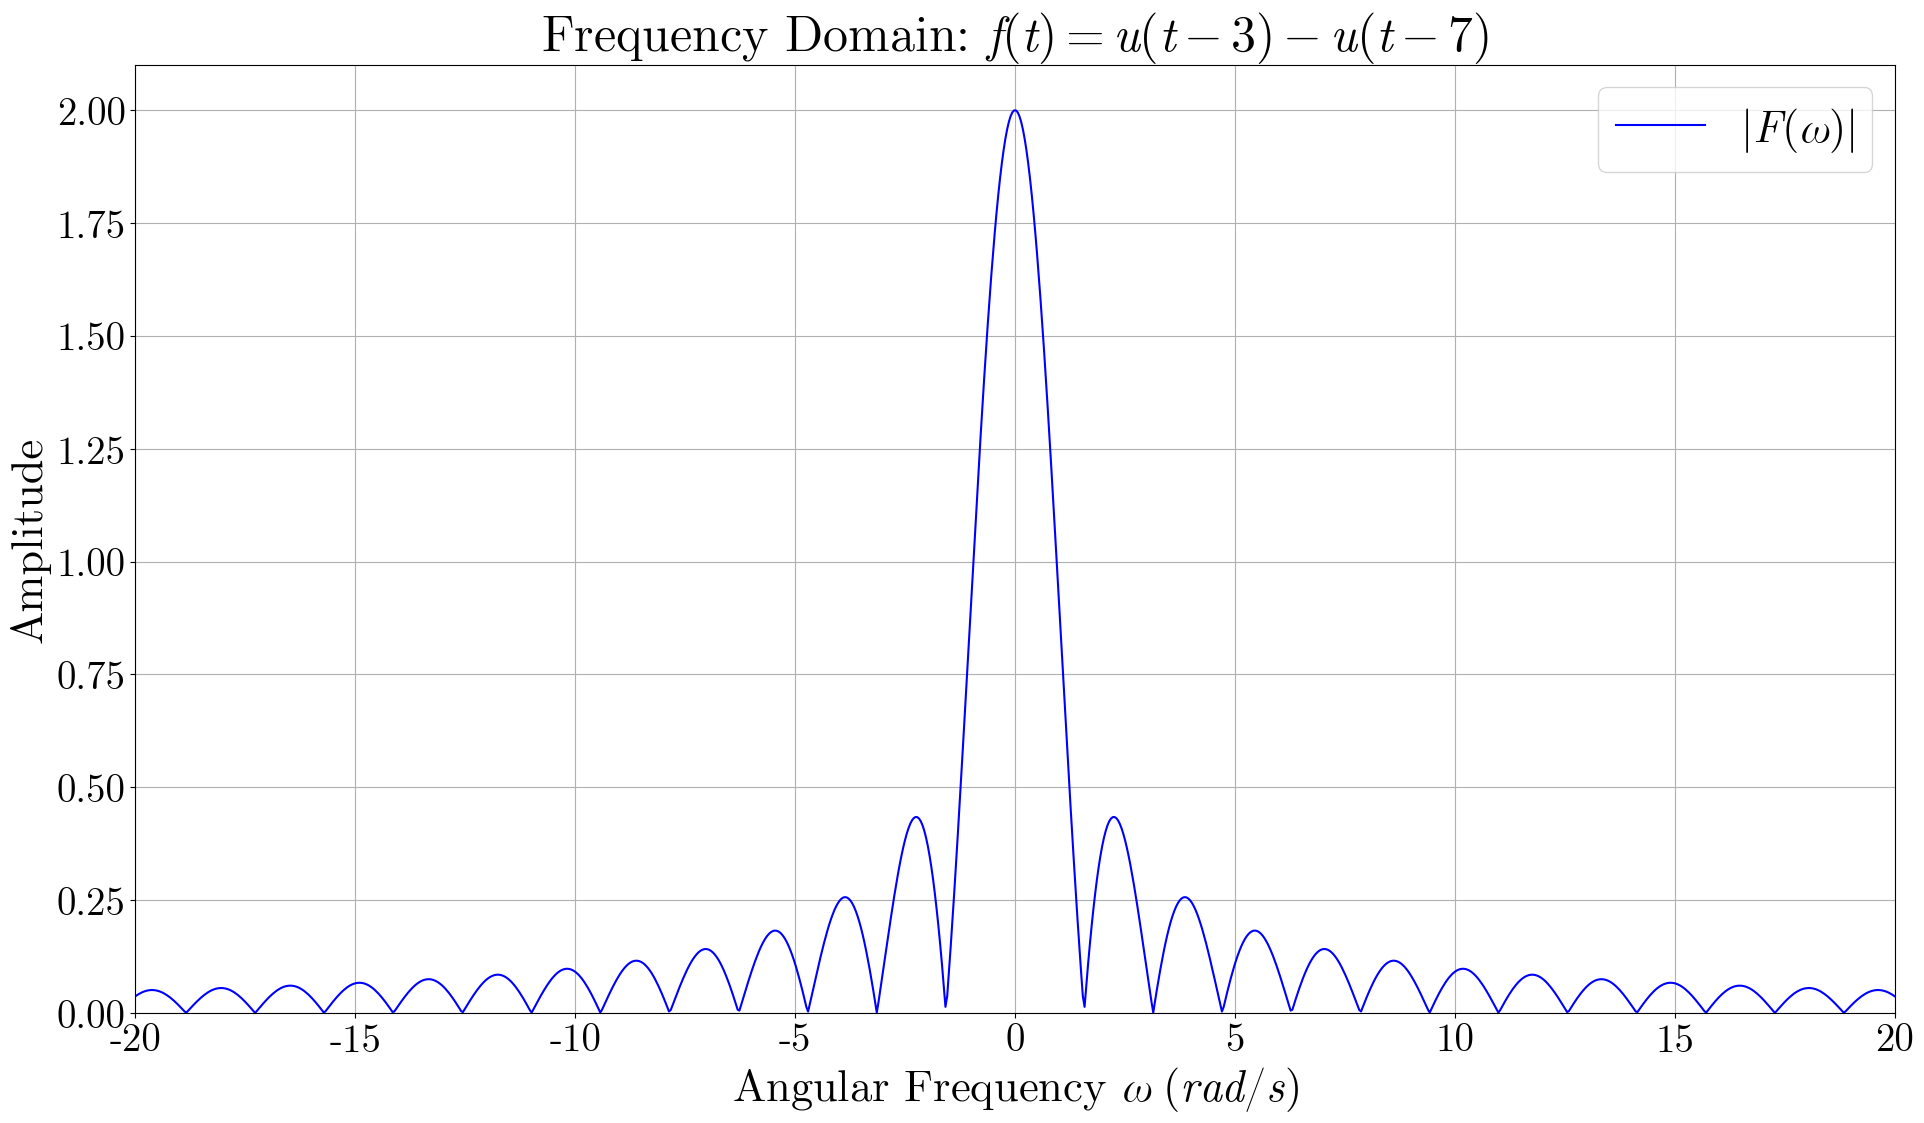

In [ ]:
# Define frequency range (angular frequency omega)
omega = np.linspace(-20, 20, 1000)

# Compute the amplitude of the Fourier Transform
# F(w) = 2 * e^(-jw5) * sin(2w) / w => Magnitude is 2 * |sin(2w)/w|
# Avoid division by zero using np.sinc which handles it
amplitude = 2 * np.abs(np.sinc(2 * omega / np.pi))  # np.sinc(x) = sin(pi x)/(pi x)

# Plot
plt.figure(figsize=(20, 12))
plt.plot(omega, amplitude, label=r'$|F(\omega)|$', color='blue')
plt.title('Frequency Domain: $f(t) = u(t-3) - u(t-7)$')
plt.xlabel(r'Angular Frequency $\omega\ (rad/s)$')
plt.ylabel('Amplitude')
plt.xlim(-20,20)
plt.ylim(0, 2.1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The peak at $0\ rad/s$ means that this is a DC component (there is no oscillation in the signal). The combination of these sine waves together make up the rectangular pulse we see in the time domain.

> **Bonus:** Modify your function if the machine turns ON at $t=2s$ instead

Our $f(t)$ is modified as:

$$
f(t) =
\begin{cases}
0, & t < 2\ or\ t \geq 7s\\
1, & t \geq 0
\end{cases}
$$

$$f(t)=u(t-2) - u(t-7)$$

The Laplace Transform is evaluated as:

$$
\mathcal{L}\{f(t)\} = \mathcal{L}\{u(t-2)\} - \mathcal{L}\{u(t-7)\}\ \\
\\[1em]
\boxed{\mathcal{L}\{f(t)\} = \frac{e^{-2s}}{s} - \frac{e^{-7s}}{s}}
$$

Now the pulse is observed starting at 2 seconds (delay) and lasting for 5 seconds (width).

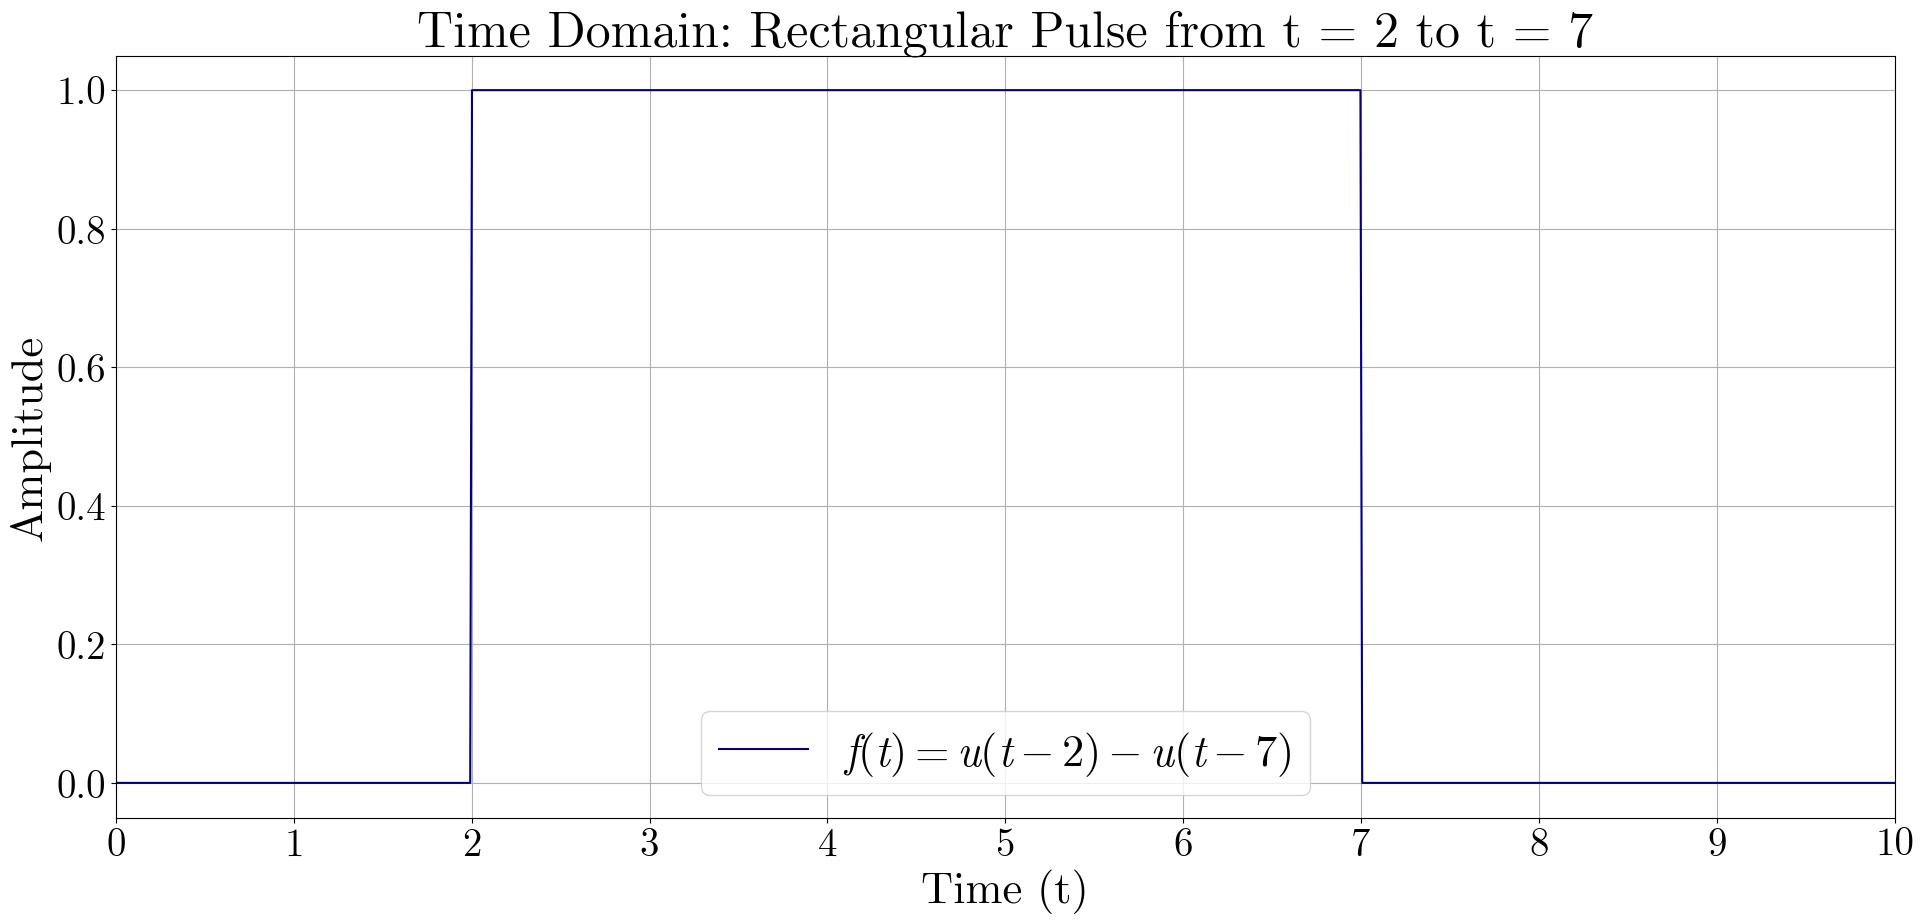

In [ ]:
# Define time values
t = np.linspace(0, 10, 1000)

# Define the rectangular pulse: f(t) = u(t-3) - u(t-7)
f_t = np.where((t >= 2) & (t < 7), 1, 0)

# Plot the time-domain signal
plt.figure(figsize=(20, 10))
plt.plot(t, f_t, label=r'$f(t) = u(t-2) - u(t-7)$', color='navy')
plt.title("Time Domain: Rectangular Pulse from t = 2 to t = 7")
plt.xlabel("Time (t)")
plt.ylabel("Amplitude")
plt.xticks(np.arange(0, 11, 1))
plt.xlim(0,10)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 2. Dirac Delta and The Mysterious Shockwave



As the pulse hitting the spaceship lasts for infinitesimally small time but has very high force, the force can be modelled mathematically as:

$$
f(t) =
\begin{cases}
\infty, & 5 - \frac{h}{2} \leq t \leq 5 + \frac{h}{2} \\
0, & t \neq 5
\end{cases}
$$

where $h$ is infinitesimally small and $h/2$ denotes radius around $t=5$.
Since $h$ is infinitesimally small, the $\infty$ can be written as $\frac{1}{h}$ $[\frac{1}{h} \to \infty]$

Rewriting $f(t)$,

$$
f(t) =
\begin{cases}
\frac{1}{h}, & 5 - \frac{h}{2} \leq t \leq 5 + \frac{h}{2} \\
0, & t \neq 5
\end{cases}
$$

where $h \to 0$.
This is similar to the Dirac Delta Function that is delayed by 5 seconds, ie., $\displaystyle \lim_{h \to 0} f(t) = \delta(t-5)$.
Its Laplace Transform is evaluated as:

$$
\begin{aligned}
\mathcal{L}\{\delta(t-5)\} &= \mathcal{L}\{\lim_{h \to 0} f(t)\} \\
&= \lim_{h \to 0} \mathcal{L}\{f(t)\} \\
\end{aligned}
$$

Evaluating $\mathcal{L}\{f(t)\}$:

$$
\begin{aligned}
\mathcal{L}\{f(t)\} &= \int_{0}^{\infty} f(t) e^{-st} \, dt \\
&= \int_{5 - \frac{h}{2}}^{5 + \frac{h}{2}} \frac{1}{h} e^{-st} \, dt \\

\mathcal{L}\{f(t)\} &= \frac{1}{h} \int_{5 - \frac{h}{2}}^{5 + \frac{h}{2}} e^{-st} \, dt \\
&= \frac{1}{h} \left[ \frac{-1}{s} e^{-st} \right]_{5 - \frac{h}{2}}^{5 + \frac{h}{2}} \\
&= \frac{1}{h s} \left( e^{-s(5 - \frac{h}{2})} - e^{-s(5 + \frac{h}{2})} \right) \\

&= \frac{1}{h s} e^{-5s} \left( e^{\frac{sh}{2}} - e^{-\frac{sh}{2}} \right) \\
\mathcal{L}\{f(t)\} &= \frac{1}{h s} e^{-5s} \cdot 2\sinh\left( \frac{sh}{2} \right) \\
\end{aligned}
$$

Now evaluating $\lim_{h \to 0} \mathcal{L}\{f(t)\}$:

$$
\lim_{h \to 0} \mathcal{L}\{f(t)\} = \lim_{h \to 0} \left( \frac{1}{h s} e^{-5s} \cdot 2\sinh\left( \frac{sh}{2} \right) \right)
= e^{-5s} \hspace{1cm}\left[\text{As}\ \lim_{h \to 0} \frac{\frac{2}{s}\sin \frac{s}{2}h}{h} = 1\right]
\\[1em]
\boxed{\mathcal{L}\{\delta(t-5)\} = e^{-5s}}
$$

The 5 in $e^{-5s}$ indicates a time delay of 5 seconds. We will plot this function in Question 5.

**Usefulness in Engineering Applications:**

* With the Laplace transform of the Dirac Delta function, we can analyze systems subjected to sudden, impulsive forces or events, hence the name "Impulse Function". We can determine the system's impulse response, which is crucial for understanding its stability and behavior.
* In signal processing, we can use it to model and analyze signals with sharp peaks or discontinuities.
* In mechanics, it is used to model impulsive forces such as impacts, collisions, mysterious energy pulses, etc.

> **Bonus:** If a second shockwave occurs at t = 10s, modify your function and find the new Laplace Transform.

This is simply equivalent to adding a second Dirac Delta delayed by 10 seconds:

$$
\lim_{h \to 0} f(t) = \delta(t-5) + \delta(t-10)
$$

Its Laplace Transform is computed as:

$$
\mathcal{L}\{\lim_{h \to 0} f(t)\} = \mathcal{L}\{\delta(t-5)\} + \mathcal{L}\{\delta(t-10)\}\ \text{(Linearity Property)}
\\[1em]
\boxed{\mathcal{L}\{\lim_{h \to 0} f(t)\} = e^{-5s} + e^{-10s}}
$$


### 3. Piecewise Functions and The Robo-Guard Challenge



We aim to design a security robot that follows the piecewise **speed** function:

$$
v(t) =
\begin{cases}
2, & 0 \leq t < 3 \\
0, & 3 \leq t < 6 \\
4, & t \geq 6 \\
\end{cases}
$$

It can be rewritten using **Heaviside Unit Step Function** as:

$$
v(t) = 2[u(t) - u(t-3)] + 4u(t-6)
$$

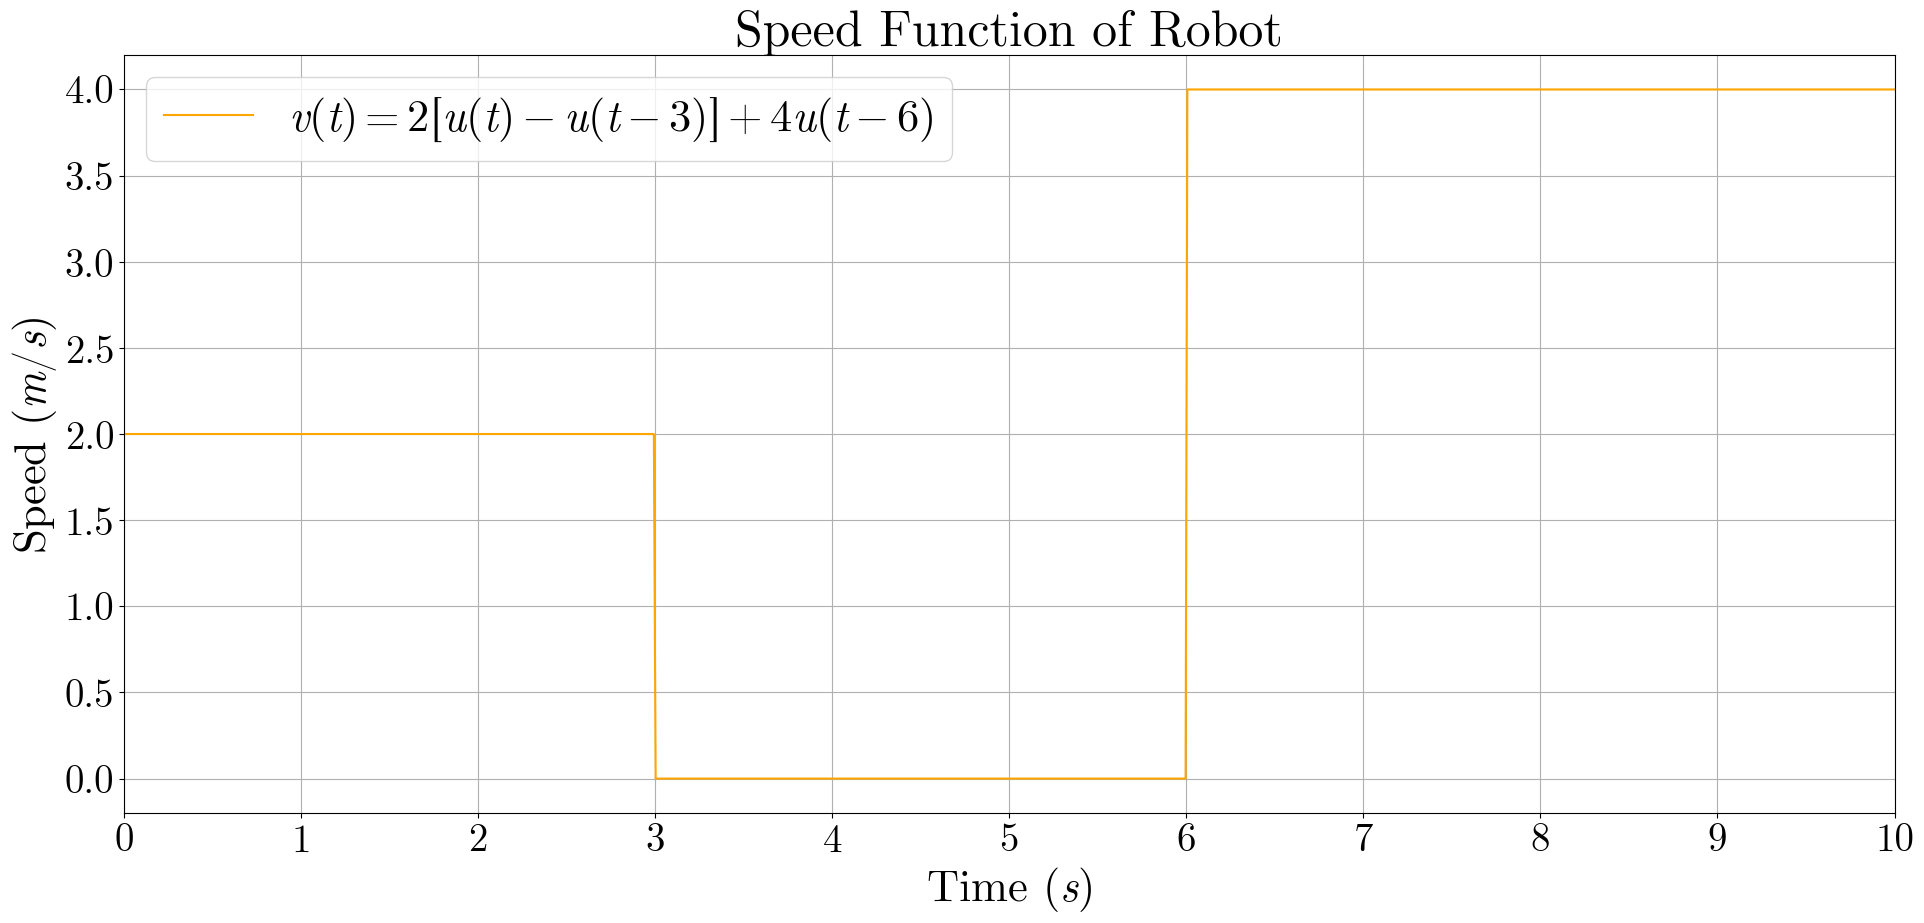

In [ ]:
t = np.linspace(0, 10, 1000)

# Define the speed function: v(t) = 2[u(t) - u(t-3)] + 4u(t-6)
v = np.where(t < 3, 2, np.where(t < 6, 0, 4))

plt.figure(figsize=(20, 10))
plt.plot(t, v, label=r'$v(t) = 2[u(t) - u(t-3)] + 4u(t-6)$', color='orange')
plt.title("Speed Function of Robot")
plt.xlabel(r"Time $(s)$")
plt.ylabel(r"Speed $(m/s)$")
plt.xticks(np.arange(0, 11, 1))
plt.xlim(0, 10)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Computing the Laplace Transform of $v(t)$,

$$
\begin{aligned}
\mathcal{L}\{v(t)\} &= 2[\mathcal{L}\{u(t)\} - \mathcal{L}\{u(t-3)\}] + 4\mathcal{L}\{u(t-6)\}\ \text{(Linearity Property)} \\
&= \frac{2[e^{-0s} - e^{-3s}]}{s} + 4\frac{e^{-6s}}{s} \quad \left[\text{As}\ \mathcal{L}\{u(t - a)\} = \frac{e^{-as}}{s}\right] \\
\end{aligned} \\

\boxed{\mathcal{L}\{v(t)\} = \frac{1}{s}\left[2\left(1-e^{-3s}\right) + 4e^{-6s}\right]}
$$

**Application of this Laplace Transform in system behavior:**

Lets say we want to find the position of the robot. Say we don't know the speed function of the robot beforehand (we can think of this as a car being accelerated manually). Whatever may be the speed function, the position can be found out by integrating the function instantaneously.

In electrical engineering, we can use an analog integrator circuit to get the integration of the input signal as the output signal.

Using the transfer function, we can easily find the function of the output voltage signal, without needing to go through complex frequency-domain algebra. The transfer function can be written in the form:

$$
\mathbf{H}(\omega) = \frac{\mathbf{N}(\omega)}{\mathbf{D}(\omega)}
$$

where $\mathbf{N}(\omega)\ \&\ \mathbf{D}(\omega)$ are not necessarily the same expressions of the input and output functions respectively.

Lets go back to our original functions. Let $v(t)$ be the speed function and $x(t)$ be the position function. The relation between the two can be given as follows:

$$
x(t) = \int v(t) dx
$$

Applying Laplace Transform, we get:
$$
\mathbf{X}(s) = \frac{1}{s} \mathbf{V}(s)
$$

where $V(s)$ and $X(s)$ are the Laplace Transforms of $v(t)$ and $x(t)$ respectively. We have:

$$
\mathbf{H}(s) = \frac{\mathbf{X}(s)}{\mathbf{V}(s)} = \frac{\mathbf{V_{out}}(s)}{\mathbf{V_{in}}(s)} = \frac{1}{s}
$$

where $\mathbf{V_{in}}(s)$ and $\mathbf{V_{out}}(s)$ are the Laplace Transforms of the input and output voltage signal functions respectively. To go to the frequency domain from the "s-domain" (ie., the Laplace Transform), we replace $s$ with $s = j\omega$ ($\sigma = 0$ because we want no decay in our output signal.):

$$
\mathbf{V_{out}}(j\omega) = \frac{1}{j\omega} \mathbf{V_{in}}(j\omega)
$$

Lets set this aside for a bit and look at the aforementioned analog integrator circuit.

The op-amp integrator circuit (involving an Operational Amplifier) can give an output signal proportional to the integral of the input signal. This can be represented mathematically as:

$$
v_{out}(t) = -\frac{1}{RC}\int_{0}^{t}v_{in}(t)
$$

Applying Laplace Transform,

$$
\mathbf{V_{out}}(s) = -\frac{1}{sRC} \mathbf{V_{in}}(s)
$$

This matches our model relation if $RC = 1$ and if the signal is also inverted. Therefore, if we want to find the position, we tap the signal (ideally a voltage) that is sent to the motor of the robot, feed it into the op-amp integrator circuit, invert the output and measure the output voltage. This output voltage can multiplied with the value of $RC$ pertaining to the integrator circuit to get the distance.

<p align="center">
Inverting Op-amp Integrator Circuit (Fundamentals of Electric Circuits, Alexander & Sadiku):<br>
    <img src="https://github.com/pseudoforceyt/projectTitin/blob/main/stream/opamp_integrator.png?raw=true" alt="Inverting Op-amp Integrator" width=500>
</p>

This example is just for illustrating the relation between the Laplace Transform and the system behavior, and assumes ideal conditions. It does not take into account the possible violations of the limits of the op-amp.

For more complex analog computations, Laplace (and Fourier) transforms can prove to be easier to work with than a straightforward integral/differential equation.



> **Bonus:** Modify the function if the robot starts at 3 m/s instead of 2 m/s.

Modified Function:

$$v(t) = \mathbf{3}[u(t) - u(t-3)] + 4u(t-6)$$

And its Laplace Transform:

$$\mathcal{L}\{v(t)\} = \frac{1}{s}\left[3\left(1-e^{-3s}\right) + 4e^{-6s}\right]$$

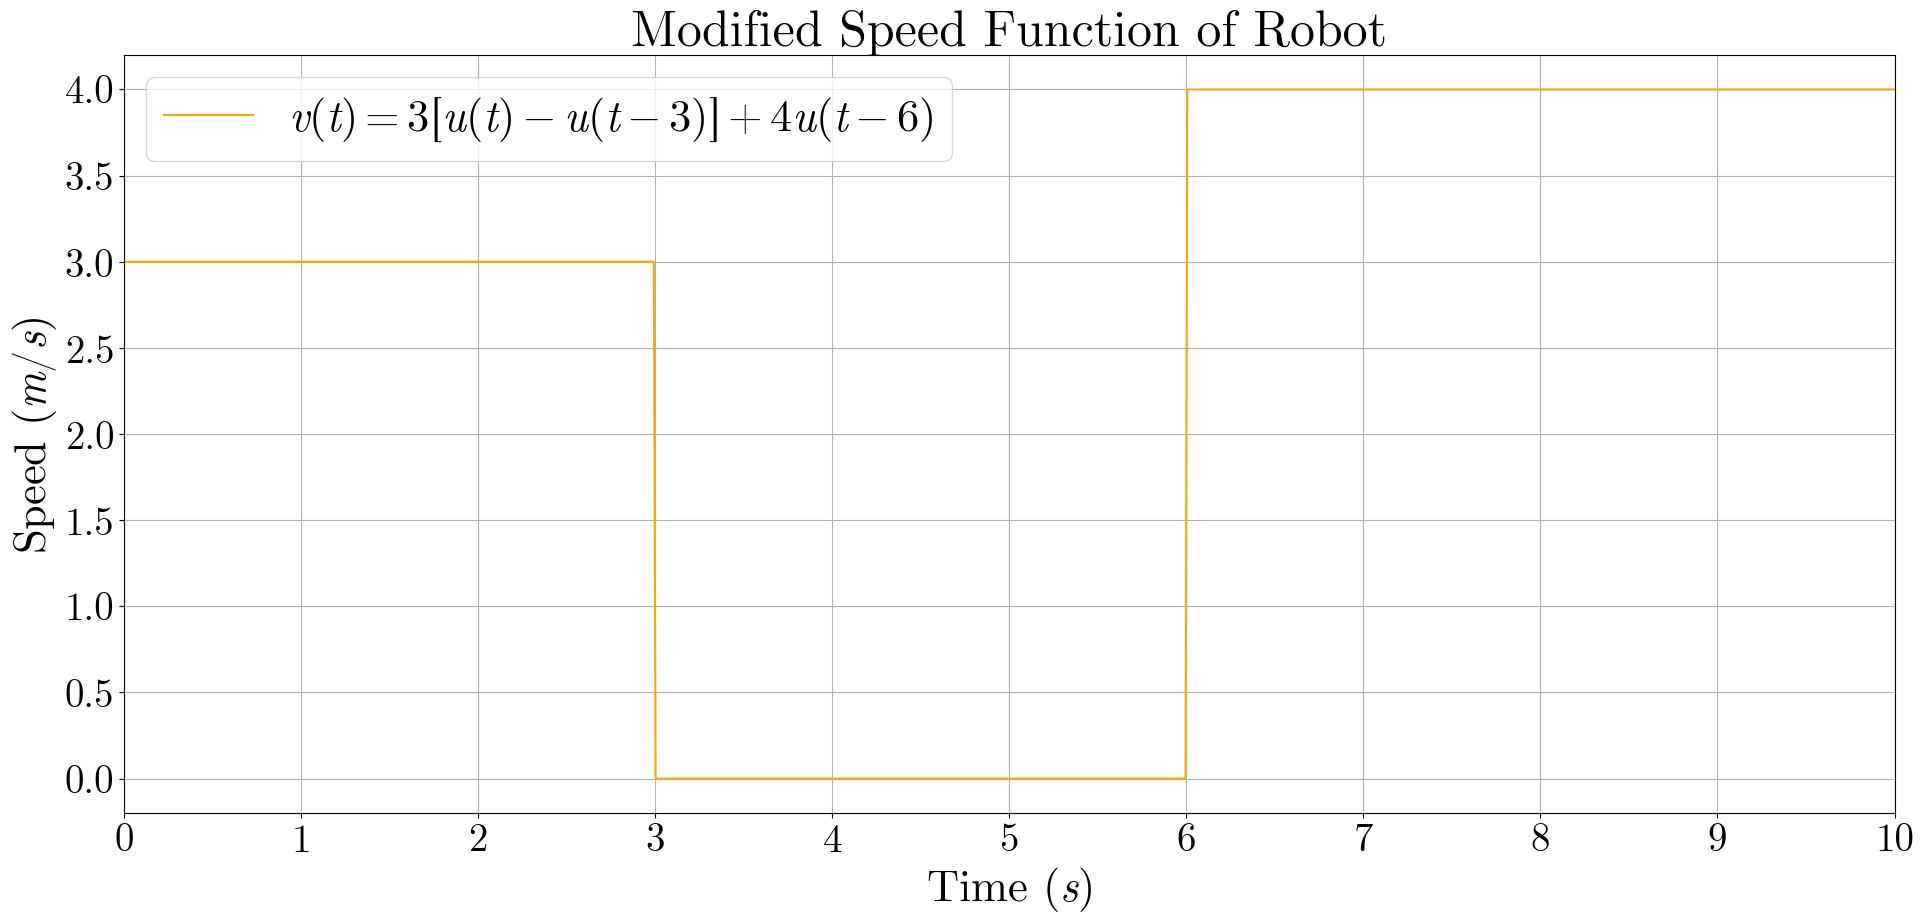

In [ ]:
t = np.linspace(0, 10, 1000)
v = np.where(t < 3, 3, np.where(t < 6, 0, 4))

plt.figure(figsize=(20, 10))
plt.plot(t, v, label=r'$v(t) = 3[u(t) - u(t-3)] + 4u(t-6)$', color='orange')
plt.title("Modified Speed Function of Robot")
plt.xlabel(r"Time $(s)$")
plt.ylabel(r"Speed $(m/s)$")
plt.xticks(np.arange(0, 11, 1))
plt.xlim(0, 10)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 4. Periodic Functions and The Time Loop Puzzle



A mysterious clock I see... not so mysterious anymore now that we know its behavior.

To turn the light ON (1) and OFF (0), we can again utilise the Heaviside Unit Step Function. We can make it periodic by composing a periodic function with the Unit Step Function. For our case here, where the circuit is ON from $t=0$, we can use the sine function:

$$
g(t) = u(\sin t)
$$

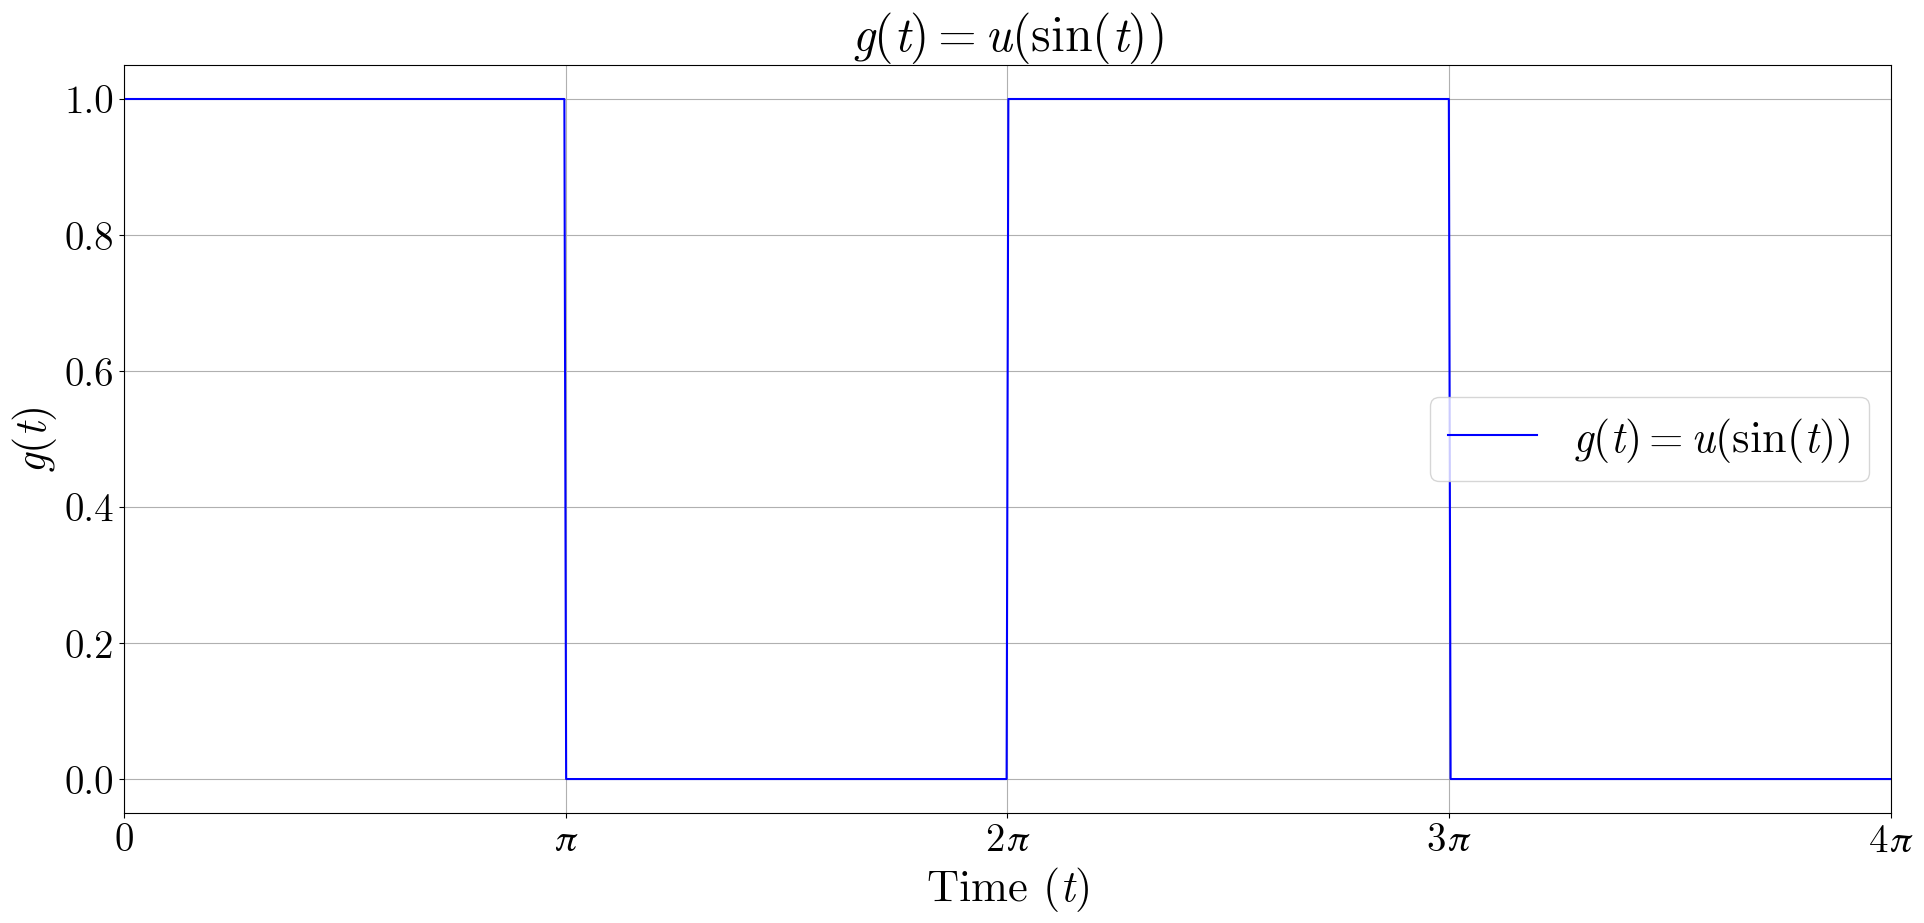

In [ ]:
# Define time values in steps of pi
t = np.linspace(0, 4 * np.pi, 1000)

# Define g(t) = u(sin(t))
g_t = np.where(np.sin(t) >= 0, 1, 0)  # Heaviside function applied to sin(t)

# Plot the function
plt.figure(figsize=(20, 10))
plt.plot(t, g_t, label=r'$g(t) = u(\sin(t))$', color='blue')
plt.xticks(np.arange(0, 4 * np.pi + np.pi, np.pi),
           [r'$0$', r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$'])  # X-axis in steps of pi
plt.title(r"$g(t) = u(\sin(t))$")
plt.xlabel(r"Time $(t)$")
plt.ylabel(r"$g(t)$")
plt.xlim(0, 4 * np.pi)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

But wait! The time period here is $2\pi$! So we have to change the argument of the sine function such that our time period becomes 4. This can be done by:

$$
f(t) = u\left(\sin \frac{\pi t}{2}\right)
$$

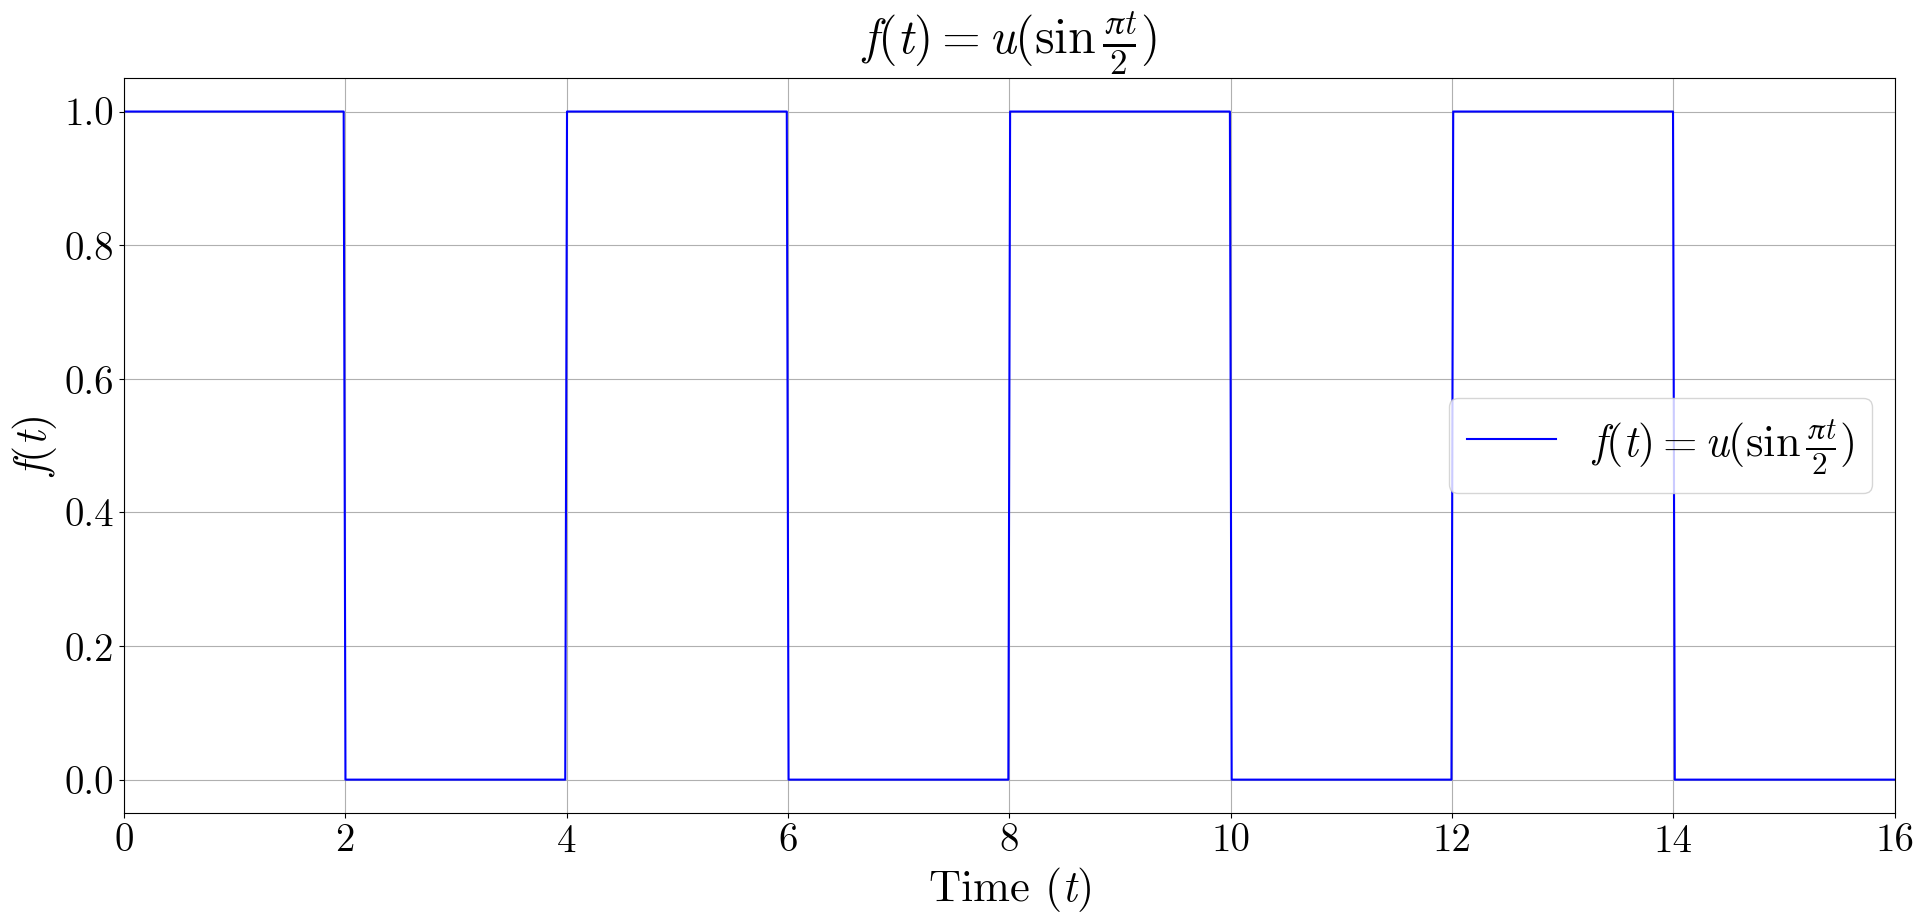

In [ ]:
t = np.linspace(0, 16, 1000)

# Define f(t) = u(sin(pi*t/2))
f_t = np.where(np.sin(np.pi*t/2) >= 0, 1, 0)  # Heaviside function applied to sin(t)

# Plot the function
plt.figure(figsize=(20, 10))
plt.plot(t, f_t, label=r'$f(t) = u(\sin \frac{\pi t}{2})$', color='blue')
plt.title(r"$f(t) = u(\sin \frac{\pi t}{2})$")
plt.xlabel(r"Time $(t)$")
plt.ylabel(r"$f(t)$")
plt.xlim(0,16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

This matches our clock's behavior. Computing the Laplace Transform of $f(t)$:

We know that for a periodic function, $f(t) = f(t+P)$ where P is the period (which in our case, $P = 4s$)

By definition,
$$

\mathcal{L}\{f(t)\} = \int_0^\infty e^{-st}f(t)\,dt \\
= \int_0^{P} e^{-st}f(t)\,dt + \int_{P}^\infty e^{-st}f(t)\,dt \hspace{1em} \text{(1)}\\

$$

Now,
$$
\begin{aligned}
\int_{P}^\infty e^{-st}f(t)\,dt &= \int_0^\infty e^{-s(x+P)}f(x+P)\,dx \\
&= e^{-sP} \cdot \int_0^\infty e^{-sx} f(x)\,dx \quad \left[\text{As}\ f(x + P) = f(x)\right] \\
&= e^{-sP} \cdot \int_0^\infty e^{-st} f(t)\,dt \quad \left[\text{Changing the variable back to}\ t\right] \\
\end{aligned} \\

\boxed{\int_{P}^\infty e^{-st}f(t)\,dt = e^{-sP} \cdot \mathcal{L}\{f(t)\}}
$$

Substituting this in $\text{(1)}$,

$$
\begin{aligned}
\mathcal{L}\{f(t)\} &= \int_0^{P} e^{-st}f(t)\,dt + e^{-sP} \cdot \mathcal{L}\{f(t)\} \\
(1-e^{-Ps})\mathcal{L}\{f(t)\} &= \int_0^{P} e^{-st}f(t)\,dt \\
\end{aligned} \\
\boxed{\mathcal{L}\{f(t)\} = \frac{1}{1-e^{-Ps}}\int_0^{P} e^{-st}f(t)\,dt}
$$

Our $f(t)$ being $u\left(\sin \frac{\pi t}{2}\right)$, and $P$ being 4, its Laplace Transform would be:

$$
\begin{aligned}
\mathcal{L}\{f(t)\} &= \frac{1}{1-e^{4s}} \left(\int_0^2 e^{-st}\,dt + \int_2^4 0 \cdot e^{-st}\,dt\right) \\
&= \frac{1}{1-e^{4s}} \int_0^2 e^{-st}\,dt = \frac{1}{1-e^{4s}} \left[\frac{1-e^{-2s}}{s}\right]\\
\end{aligned} \\

\boxed{\mathcal{L}\{f(t)\} = \frac{1}{s(1+e^{-2s})}}
$$


This Laplace Transform can be used in analyzing Linear Time-Invariant systems. A **Linear Time-Invariant (LTI) System** is a system in signal processing and control theory that satisfies two key properties:

1. **Linearity**:
    - The system obeys the principles of superposition and scaling:
      - If the input is scaled by a constant, the output is scaled by the same constant.
      - If the input is a sum of signals, the output is the sum of the responses to each signal.

    Mathematically:
    $$
    \text{If } x_1(t) \to y_1(t) \text{ and } x_2(t) \to y_2(t), \text{ then } a x_1(t) + b x_2(t) \to a y_1(t) + b y_2(t),
    $$
    where $a$ and $b$ are constants.

2. **Time-Invariance**:
    - The system's behavior does not change over time. If the input is delayed by $t_0$, the output is also delayed by $t_0$.

    Mathematically:
    $$
    \text{If } x(t) \to y(t), \text{ then } x(t - t_0) \to y(t - t_0).
    $$

Key Characteristics:
- **Impulse Response**: The system's response to a Dirac delta function $\delta(t)$ completely characterizes the system.
- **Convolution**: The output of an LTI system can be computed as the convolution of the input signal with the system's impulse response:
  $$
  y(t) = x(t) * h(t) = \int_{-\infty}^\infty x(\tau) h(t - \tau) \, d\tau,
  $$
  where $h(t)$ is the impulse response.

- **Frequency Domain**: LTI systems are easily analyzed in the frequency domain using Fourier or Laplace transforms. The system's behavior is described by its transfer function $H(s)$ or $H(j\omega)$.

Applications:
- Signal processing (filters, amplifiers)
- Control systems (stability analysis)
- Communication systems (modulation, demodulation)
- Circuit Analysis (as we saw in the 3rd question)

> **Bonus:** Generalize your solution for any period T = k seconds.

Generalising our function for a time period $P = k$ (assuming that the clock turns the light ON for $0 \leq t < \frac{k}{2}$ and off for $\frac{k}{2} \leq t < k$):

$$
f(t) = u\left(\sin \frac{2\pi t}{k}\right)
$$

Computing the Laplace Transform:

$$
\begin{aligned}
\mathcal{L}\{f(t)\} &= \frac{1}{1-e^{-Ps}}\int_0^{P} e^{-st}f(t)\,dt \\
&= \frac{1}{1-e^{-ks}} \left[\frac{1-e^{-\frac{k}{2}s}}{s}\right] \\
\end{aligned} \\

\boxed{\mathcal{L}\{f(t)\} = \frac{1}{s(1+e^{-\frac{k}{2}s})}}
$$


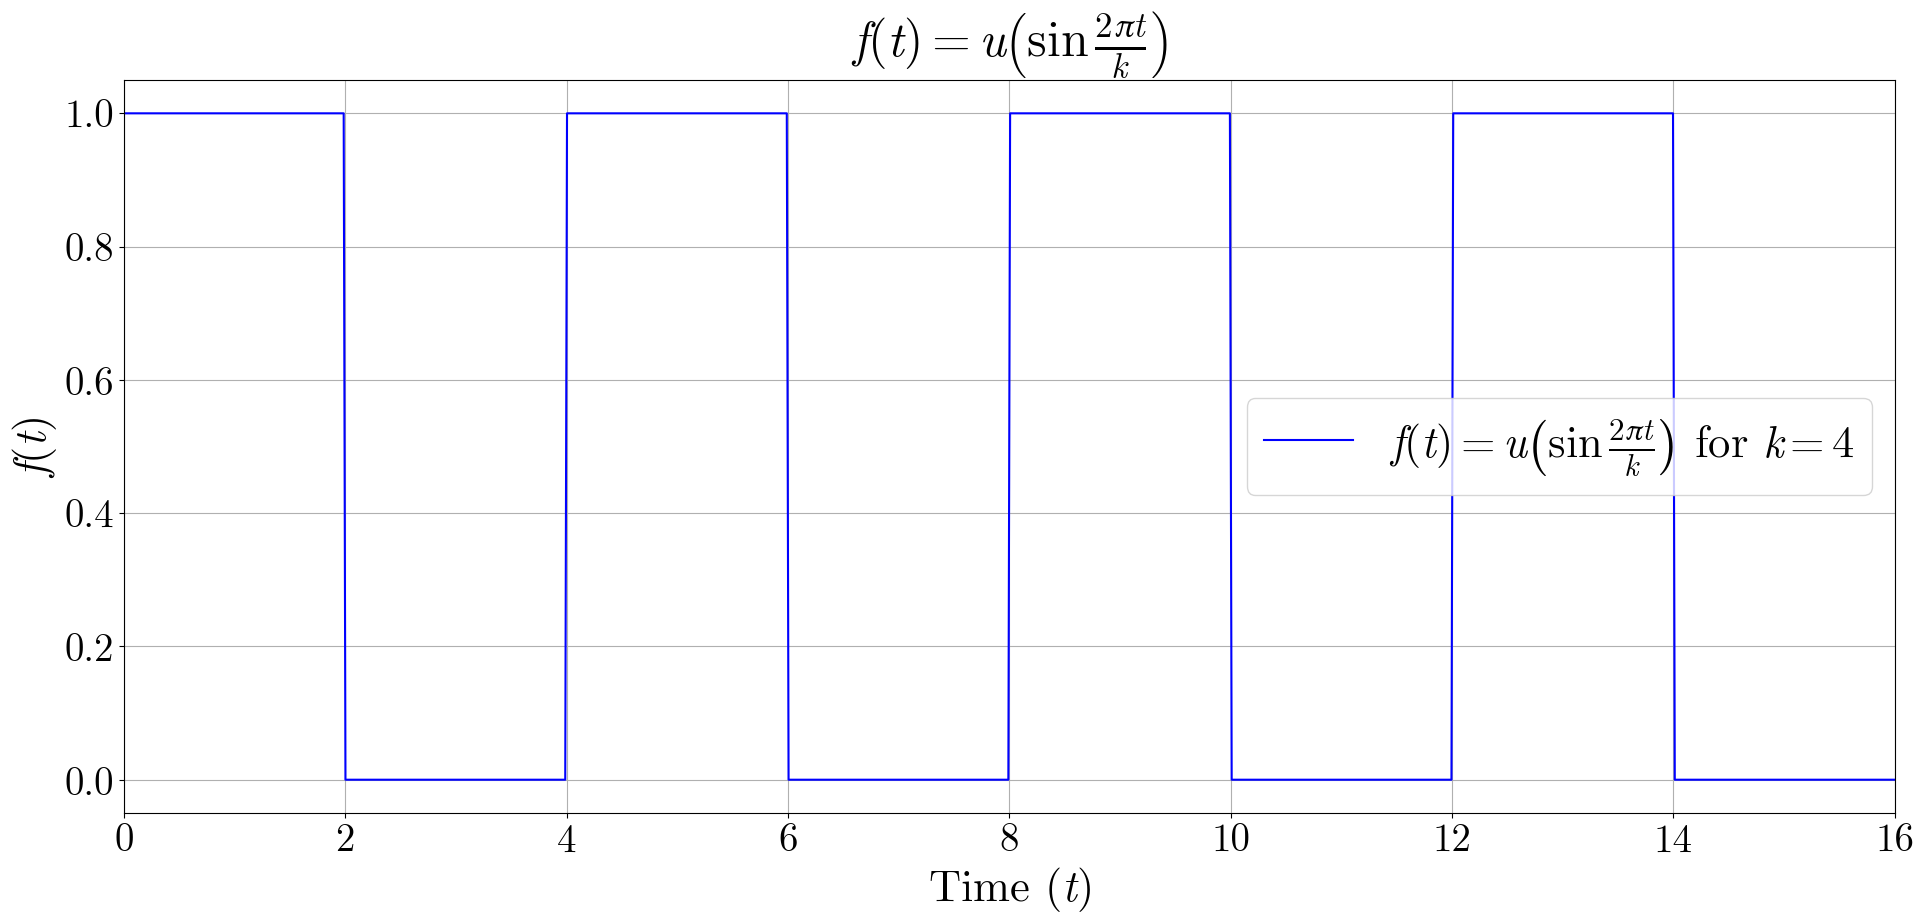

In [ ]:
t = np.linspace(0, 16, 1000)

# Modify the Period k here: default is 4 to match our original function
k = 4

# Define f(t) = u(sin(2*pi*t/k))
f_t = np.where(np.sin(2*np.pi*t/k) >= 0, 1, 0)  # Heaviside function applied to sin(t)

# Plot the function
plt.figure(figsize=(20, 10))
plt.plot(t, f_t, label=r'$f(t) = u\left(\sin \frac{2\pi t}{k}\right)$ for $k = 'f'{k}''$', color='blue')
plt.title(r"$f(t) = u\left(\sin \frac{2\pi t}{k}\right)$")
plt.xlabel(r"Time $(t)$")
plt.ylabel(r"$f(t)$")
plt.xlim(0, 16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Part - B: Code and Explore



### 5. Python/MATLAB Challenge: Visualizing Special Functions



All the graphs you have seen so far are plotted using the library `matplotlib` in Python. We will now look at the general plots of the Heaviside Unit Step Function, Dirac Delta Function and a few Periodic Functions.



#### Heaviside Unit Step Function

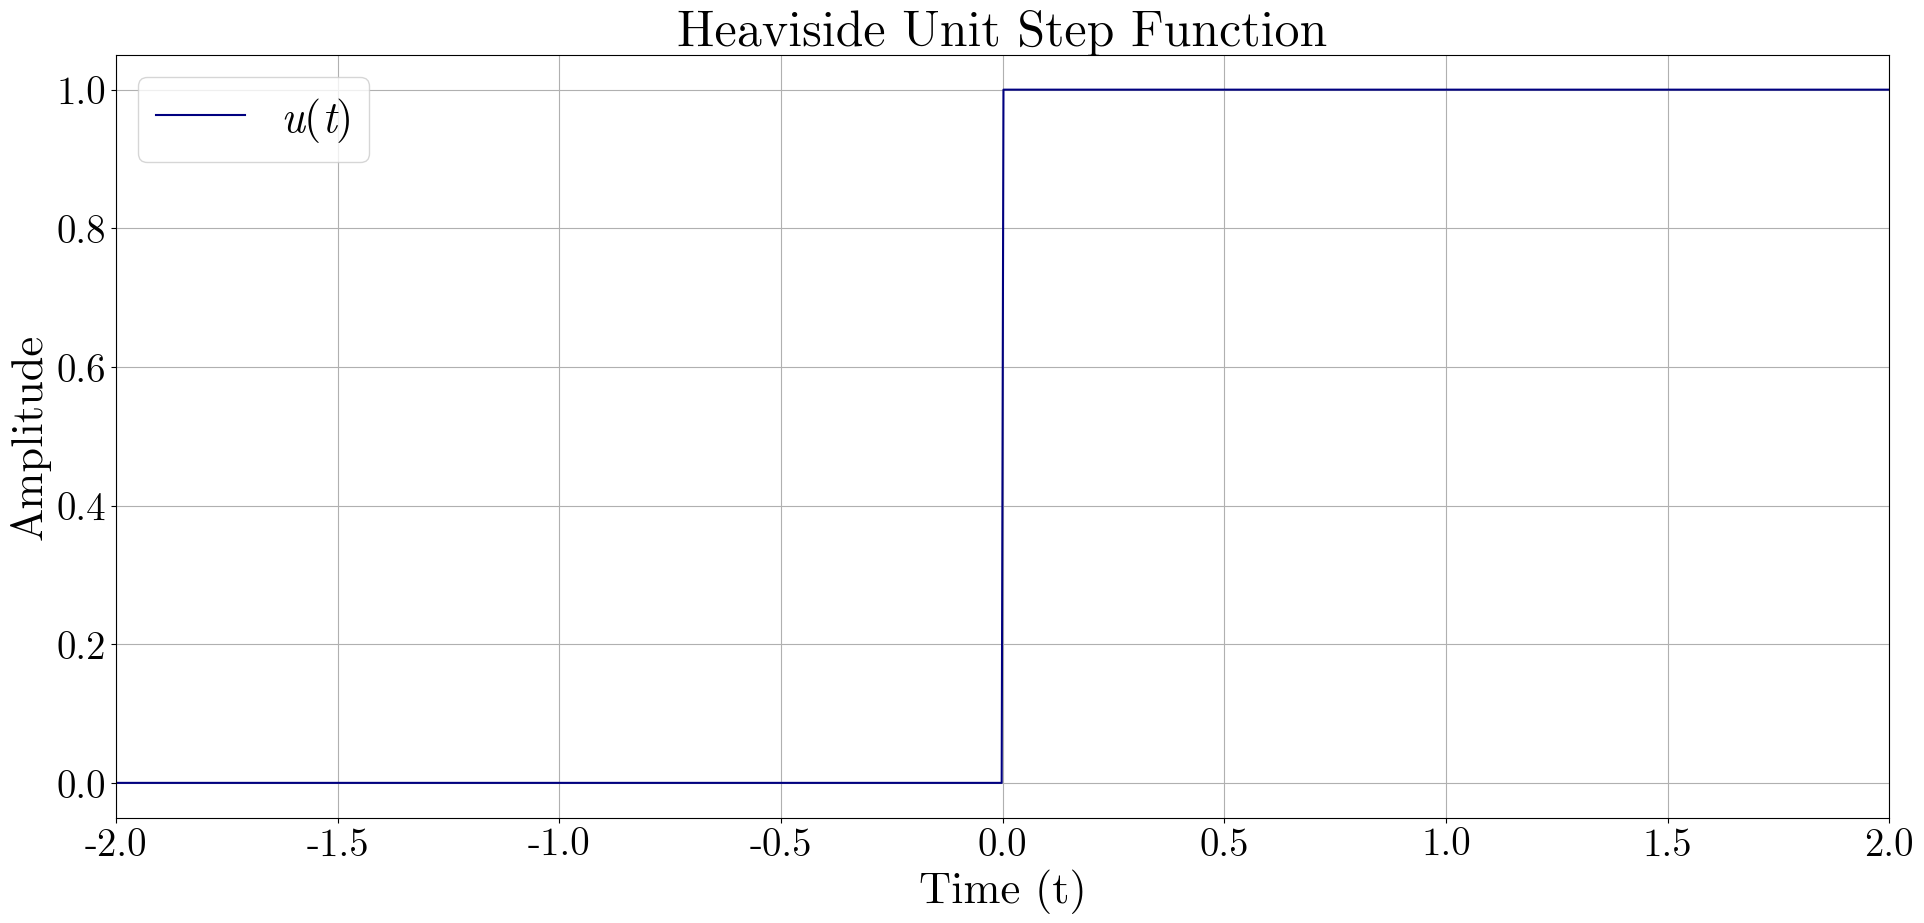

In [ ]:
# Define time values
t = np.linspace(-2, 2, 1000)

# Define the Heaviside Unit Step Function
u_t = np.where(t >= 0, 1, 0)

# Plot the function
plt.figure(figsize=(20, 10))
plt.plot(t, u_t, label=r'$u(t)$', color='navy')
plt.title("Heaviside Unit Step Function")
plt.xlabel("Time (t)")
plt.ylabel("Amplitude")
plt.xlim(-2, 2)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Dirac Delta Function



The Dirac delta function, though not a function itself, can be thought of as a limiting case of some other function, called a **mollifier**. The mollifier, which is a **smooth function** (function that has continuous derivatives of all orders) on $\mathbb{R}^n,\ n \geq 1$ denoted by $\varphi_\epsilon(x) := \epsilon^{-n}\varphi(x/\epsilon)$ for $\epsilon > 0$ has the following properties:

1. Has a **compact support** (support is the collection of points in the domain which map to non-zero values)
2. $\displaystyle \int_{\mathbb{R}^n} \varphi_(x)\,dx=1$
3. $\lim_{\epsilon \to 0} \varphi_\epsilon{x} = \delta(x)$

This third property, which yields the Dirac Delta Function, is what we are looking for.

Here we have plotted an example of a mollifier: a Gaussian curve.

$$f(x) = \frac{1}{\sqrt{2 \pi k}} e^{\large -\frac{1}{2k} \normalsize (x-a)^{2}}$$

As we move the value of 'k' closer to zero (`k_list` has values that move closer to 0 as the list progresses), this mollifier gets very narrow around its center (whose position is controlled by the 'a' value) and very tall, approximating the limiting case where they will have zero width and infinite height.

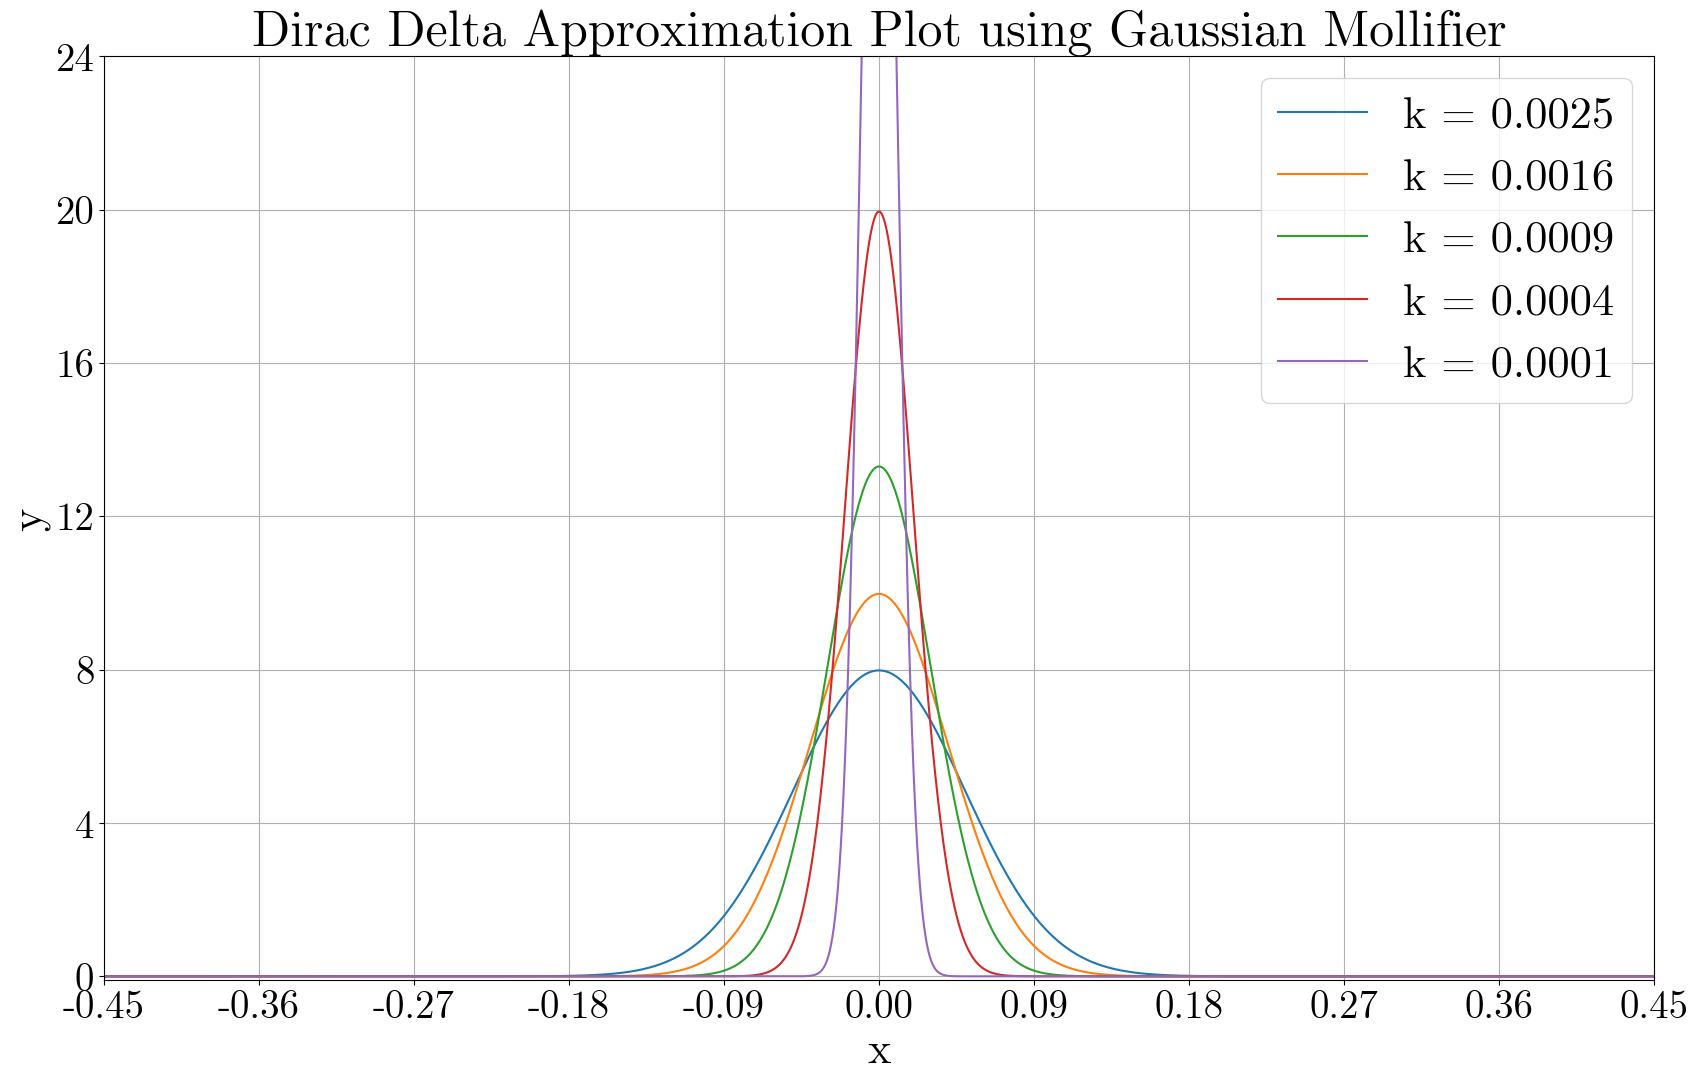

In [ ]:
x = np.linspace(-2, 2, 10000)

a = 0 # Center of the Gaussian

k_list = [(0.005 * i) ** 2 for i in range(10, 0, -2)]
y = [np.exp(-((x - a)**2)/(2*k)) / ((2 * np.pi * k) ** 0.5) for k in k_list]

plt.figure(figsize=(20, 12))
for i in range(0, 5):
    plt.plot(x, y[i], label=f"k = {round(k_list[i], 6)}")
plt.title(r"Dirac Delta Approximation Plot using Gaussian Mollifier")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-0.35, 0.35)
plt.ylim(-0.1, 10)
plt.yticks(np.arange(0, 28, 4))
plt.xticks(np.arange(-0.45, 0.46, 0.09))
plt.grid(True)
plt.legend()
plt.show()


Going back to Question 2, we can now try plotting the mysterious energy pulse. We can change the a value in the above code to 5, to shift the graph to $t=5$.

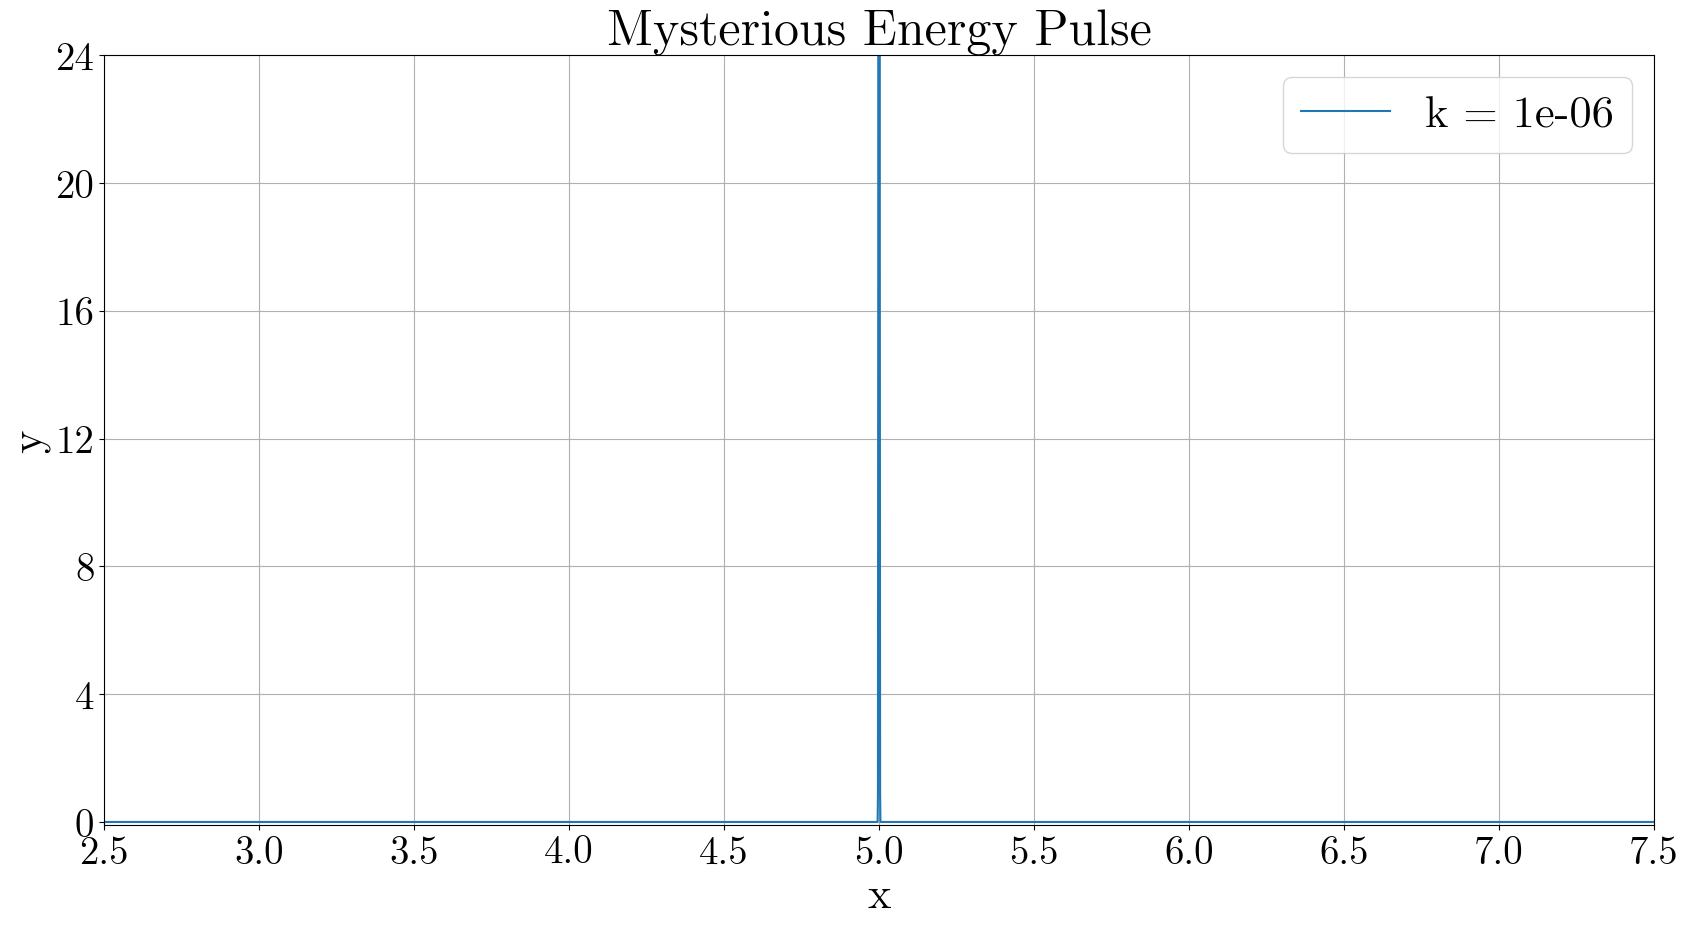

In [ ]:
x = np.linspace(0, 10, 10000)

a = 5
k = 0.000001
y = np.exp(-((x - a)**2)/(2*k)) / ((2 * np.pi * k) ** 0.5)

plt.figure(figsize=(20, 10))
plt.plot(x, y, label=f"k = {k}")
plt.title(r"Mysterious Energy Pulse")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(2.5, 7.5)
plt.ylim(-0.1, 10)
plt.yticks(np.arange(0, 28, 4))
plt.xticks(np.arange(2.5, 7.6, 0.5))
plt.grid(True)
plt.legend()
plt.show()


To plot the Bonus question, we just need to add another mollifier with `a` set to 10

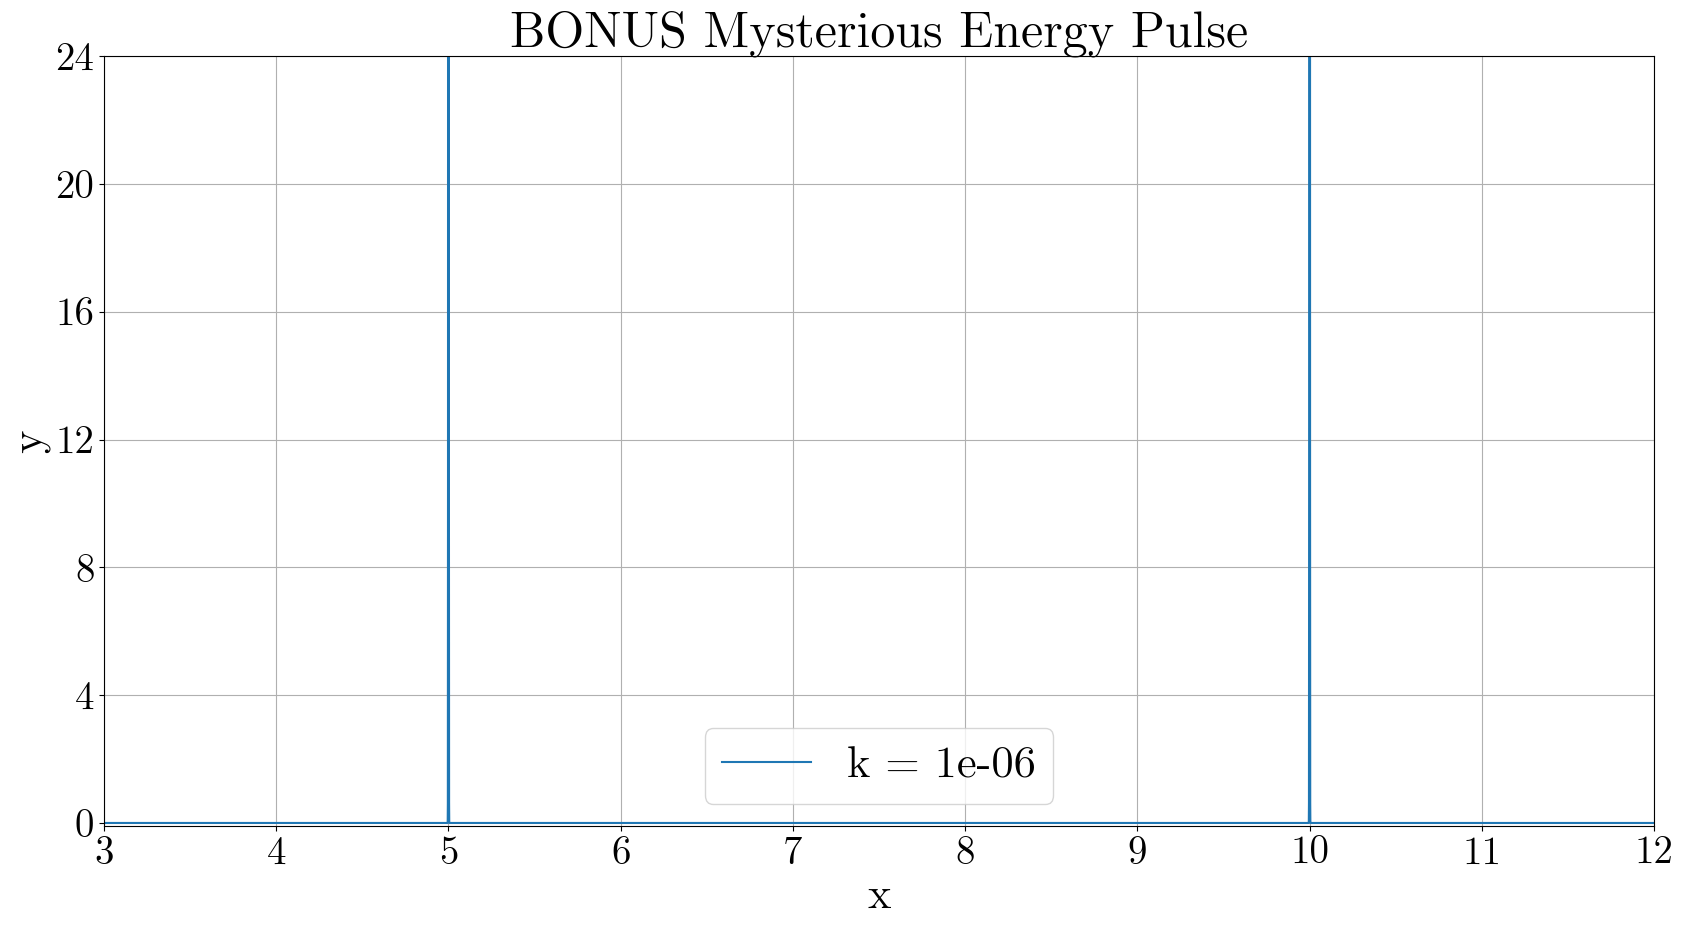

In [ ]:
x = np.linspace(3, 12, 10000)

a1, a2 = 5, 10
k = 0.000001
y1 = np.exp(-((x - a1)**2)/(2*k)) / ((2 * np.pi * k) ** 0.5) # pulse 1
y2 = np.exp(-((x - a2)**2)/(2*k)) / ((2 * np.pi * k) ** 0.5) # pulse 2
y = y1 + y2

plt.figure(figsize=(20, 10))
plt.plot(x, y, label=f"k = {k}")
plt.title(r"BONUS Mysterious Energy Pulse")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(3, 12)
plt.ylim(-0.1, 10)
plt.yticks(np.arange(0, 28, 4))
plt.xticks(np.arange(3, 13, 1))
plt.grid(True)
plt.legend()
plt.show()

#### Periodic Functions



We have 2 examples of periodic functions which are used in real life:
- **Alternating Current** (Sine Wave): $y_1 = \sin (t)$
- **Full-wave Rectified AC** (Sine folded upwards along x-axis): $y_2 = |\sin(t)|$


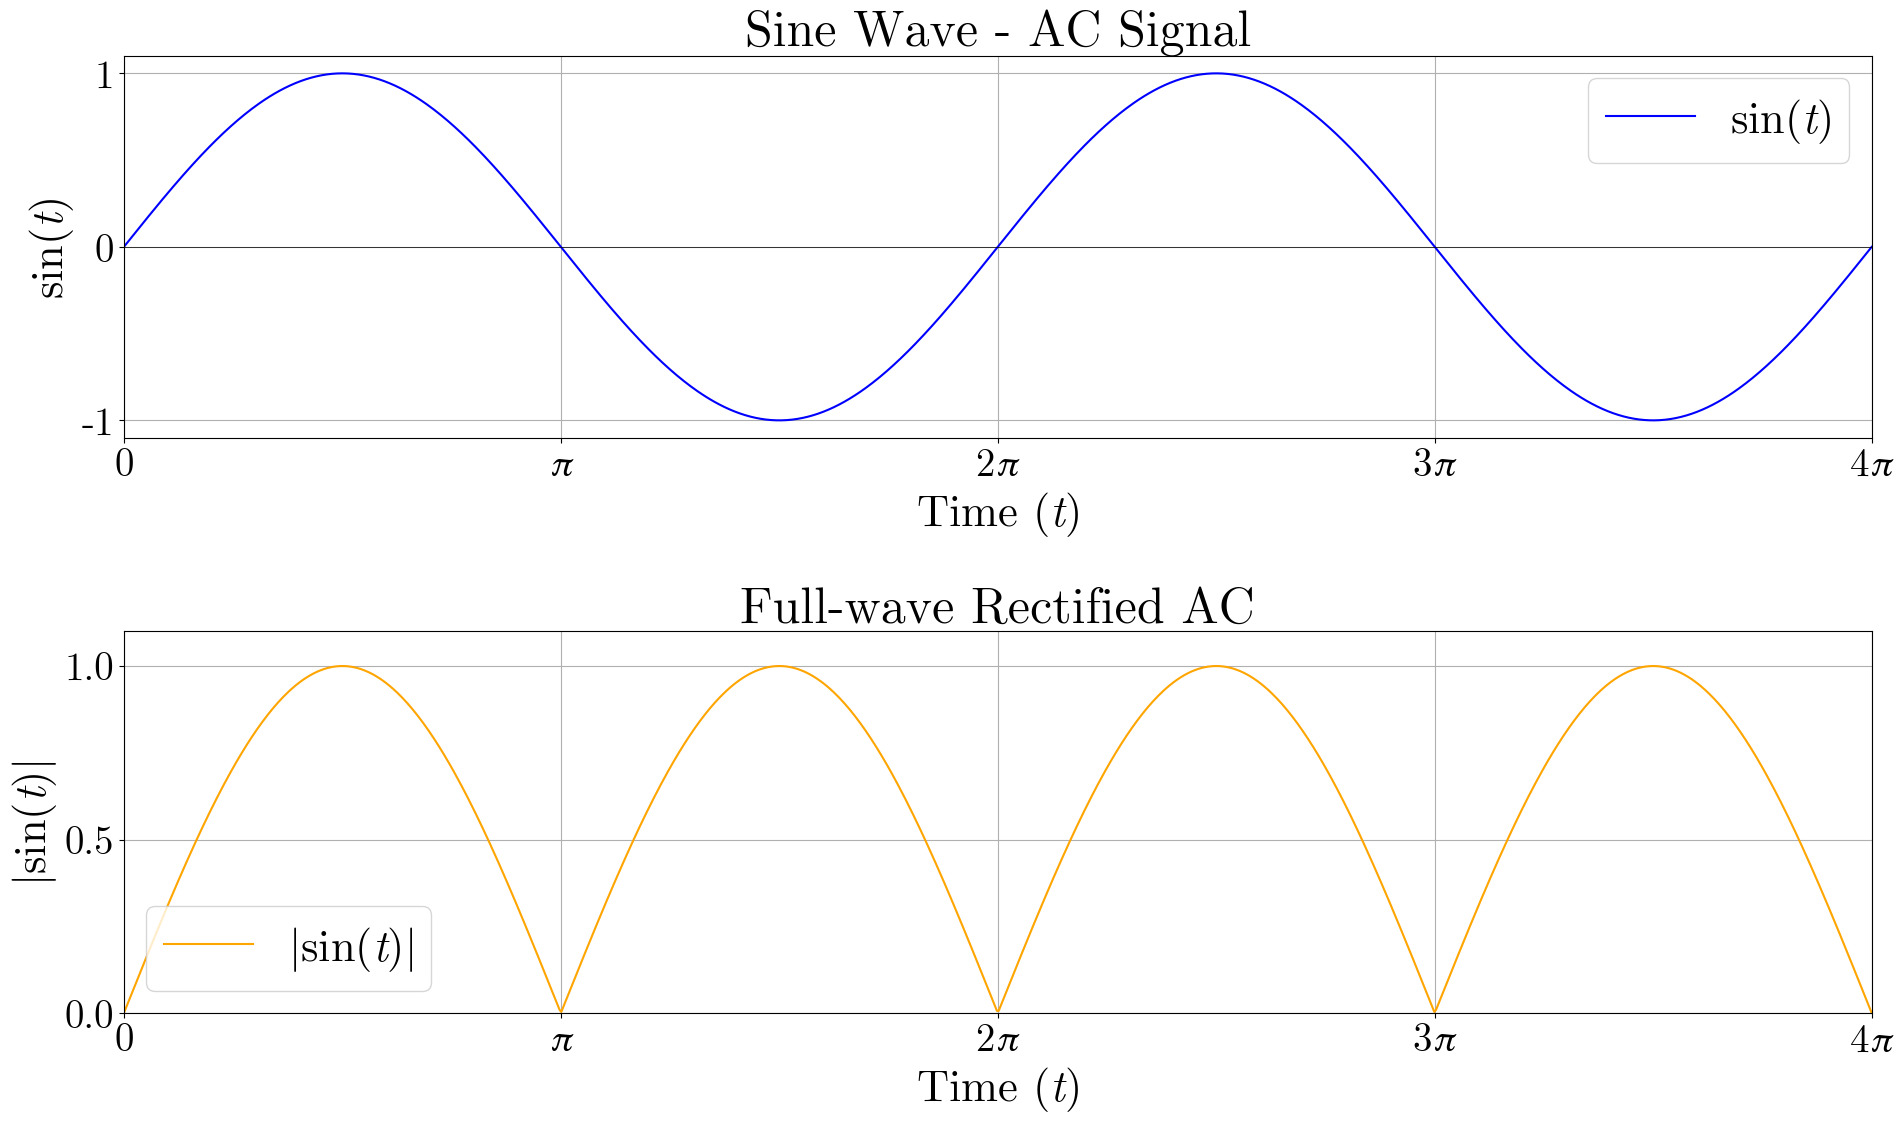

In [ ]:
# Time domain
t = np.linspace(0, 4 * np.pi, 1000)

# Define the periodic functions
y1 = np.sin(t)
y2 = np.abs(np.sin(t))

# Plotting
plt.figure(figsize=(20, 12))

plt.subplot(2, 1, 1)
plt.plot(t, y1, label=r'$\sin(t)$', color='blue')
plt.title('Sine Wave - AC Signal')
plt.xticks(np.arange(0, 4 * np.pi + np.pi, np.pi),
           [r'$0$', r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$'])
plt.xlim(0, 4 * np.pi)
plt.axhline(0, color='black', lw=0.5, ls='-')
plt.legend()
plt.xlabel(r"Time $(t)$")
plt.ylabel(r"$\sin(t)$")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, y2, label=r'$|\sin(t)|$', color='orange')
plt.title('Full-wave Rectified AC')
plt.xticks(np.arange(0, 4 * np.pi + np.pi, np.pi),
           [r'$0$', r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$'])
plt.xlim(0, 4 * np.pi)
plt.ylim(0,1.1)
plt.legend()
plt.xlabel(r"Time $(t)$")
plt.ylabel(r"$|\sin(t)|$")
plt.grid(True)

plt.tight_layout()
plt.show()


`SymPy` is a Python library for symbolic mathematics that can compute Laplace transforms symbolically, providing exact results for mathematical expressions. It is useful for solving problems analytically rather than numerically. We will now compute the Laplace Transform for all the aforementioned functions:

In [ ]:
import sympy as sp
from sympy.abc import t, s

a = sp.symbols('a', real=True, nonnegative=True)

# 1. Heaviside unit step function
u = sp.Heaviside(t-a)
laplace_u = sp.laplace_transform(u, t, s, noconds=True)

# 2. Dirac delta function
delta = sp.DiracDelta(t-a)
laplace_delta = sp.laplace_transform(delta, t, s, noconds=True)

# 3. y1 = sin(t)
y1 = sp.sin(t)
laplace_y1 = sp.laplace_transform(y1, t, s, noconds=True)

# 4. y2 = abs(sin(t))
y2 = sp.Abs(sp.sin(t))
laplace_y2 = sp.laplace_transform(y2, t, s, noconds=True)

# Print all results
print("Laplace Transform of Heaviside(t):", laplace_u)
print("Laplace Transform of DiracDelta(t):", laplace_delta)
print("Laplace Transform of sin(t):", laplace_y1)
print("Laplace Transform of |sin(t)|:", laplace_y2)


Laplace Transform of Heaviside(t): exp(-a*s)/s
Laplace Transform of DiracDelta(t): exp(-a*s)
Laplace Transform of sin(t): 1/(s**2 + 1)
Laplace Transform of |sin(t)|: coth(pi*s/2)/(s**2 + 1)


From the output, we can see that we have obtained the correct Laplace Transforms of all our functions:

$$
\begin{aligned}
\mathcal{L}\{u(t-a)\} &= \frac{e^{-as}}{s} \\
\mathcal{L}\{\delta(t-a)\} &= e^{-as} \\
\mathcal{L}\{\sin(t)\} &= \frac{1}{s^2 + 1} \\
\mathcal{L}\{|\sin(t)|\} &= \frac{1}{s^2 + 1}\cdot\coth\left(\frac{s\pi}{2}\right) \\
\end{aligned}
$$

If you don't trust sympy's answer, here is the manual verification the result of $\mathcal{L}\{|\sin(t)|\}$

Let $f(t) = |sin(t)|$. Its period $P = \pi$

$\sin(t) \geq 0$ in $[0, \pi]$, so $|\sin(t)| = \sin(t)$ over this interval.

$$
\begin{aligned}
\mathcal{L}\{f(t)\} &= \frac{1}{1 - e^{-sP}} \int_0^P e^{-st} f(t)\,dt \\
\mathcal{L}\{|\sin(t)|\} &= \frac{1}{1 - e^{-s\pi}} \int_0^{\pi} e^{-st} \sin(t)\,dt \\
\int_0^{\pi} e^{-st} \sin(t)\,dt &= \frac{1 - e^{-s\pi}(\cos(\pi) + s\sin(\pi))}{s^2 + 1} \\
&= \frac{1 + e^{-s\pi}}{s^2 + 1} \\
\mathcal{L}\{|\sin(t)|\} &= \frac{1}{1 - e^{-s\pi}}\cdot\frac{1 + e^{-s\pi}}{s^2 + 1} = \frac{e^{s\pi/2} + e^{-s\pi/2}}{e^{s\pi/2} - e^{-s\pi/2}}\cdot\frac{1}{s^2 + 1}\\
\end{aligned} \\

\boxed{\mathcal{L}\{|\sin(t)|\} = \frac{1}{s^2 + 1}\cdot\coth\left(\frac{s\pi}{2}\right)}
$$

> **Bonus:** Simulate the effect of adding damping to a periodic function

**What is damping?**
Damping is a process which reduces the amplitude of oscillations of a signal, motion or other function, over time. Damping can be interpreted mathematically as, a function (in $x$) being multiplied by a damping function that decays with $x$ (continually decreases to $0$ as $x$ increases). One practical example where a periodic function is damped is:

**Underdamping in RLC Circuit:**

The Current in a (series) RLC circuit, in an underdamped case, takes the expression following this explanation.

It is obtained as the solution to the Ordinary Differential Equation

$$
\frac{d^2i}{dt^2} + \frac{R}{L}\frac{di}{dt}+\frac{i}{LC} = 0
$$

describing the Kirchoff's Voltage Law applied on the circuit, when the auxiliary/characteristic equation $\left(m^2+\frac{R}{L}m+\frac{1}{LC} = 0\right)$ has complex conjugate roots. The two roots of the characteristic equation are given as:

$$
s = -\frac{R}{2L} \pm \sqrt{\left(\frac{R}{2L}\right)^2 - \frac{1}{LC}}
$$

Let $\alpha = \frac{R}{2L}$ and $\omega_0 = \frac{1}{\sqrt{LC}}$

The case of complex conjugate occurs when $\alpha < \omega_0$. We define $\omega_d = \sqrt{\omega_0^2 - \alpha^2}$ and write the complex conjugate roots as:

$$
s_1 = (-\alpha + j\omega_d), s_2 = (-\alpha - j\omega_d)
$$

We know that the general solution for this homogeneous differential equation will be of the form:

$$
i(t) = e^{-\alpha t}\left(A_1\cos(\omega_d t) + A_2\sin(\omega_d t)\right)
$$

This is the expression for the current in the series RLC circuit.

The coefficients can be found out by applying the initial conditions of voltage and current present in the circuit, to the differential equation and the general solution.

On observation, this is an exponential damping of the periodic sine and cosine functions, with a damping coefficient of $\alpha$ and a period of $\frac{2\pi}{\omega_d}$

This damping is due to the gradual loss of the initially stored energy by dissipation of it as heat over the resistance R in the circuit.

To plot the graph, we assume $i(0) = 0$ as a typical initial condition. This will leave us with $A_1 = 0$ and the function we need to plot becomes $sin(\omega_dt)$ damped with $e^{-\alpha t}$, ie.,

$$
f(t) = e^{-\alpha t}\sin(\omega_dt)
$$

which is the damped version of our original periodic function $\sin(t)$. Play around with the $\alpha$ and $\omega_d$ value in the code below.

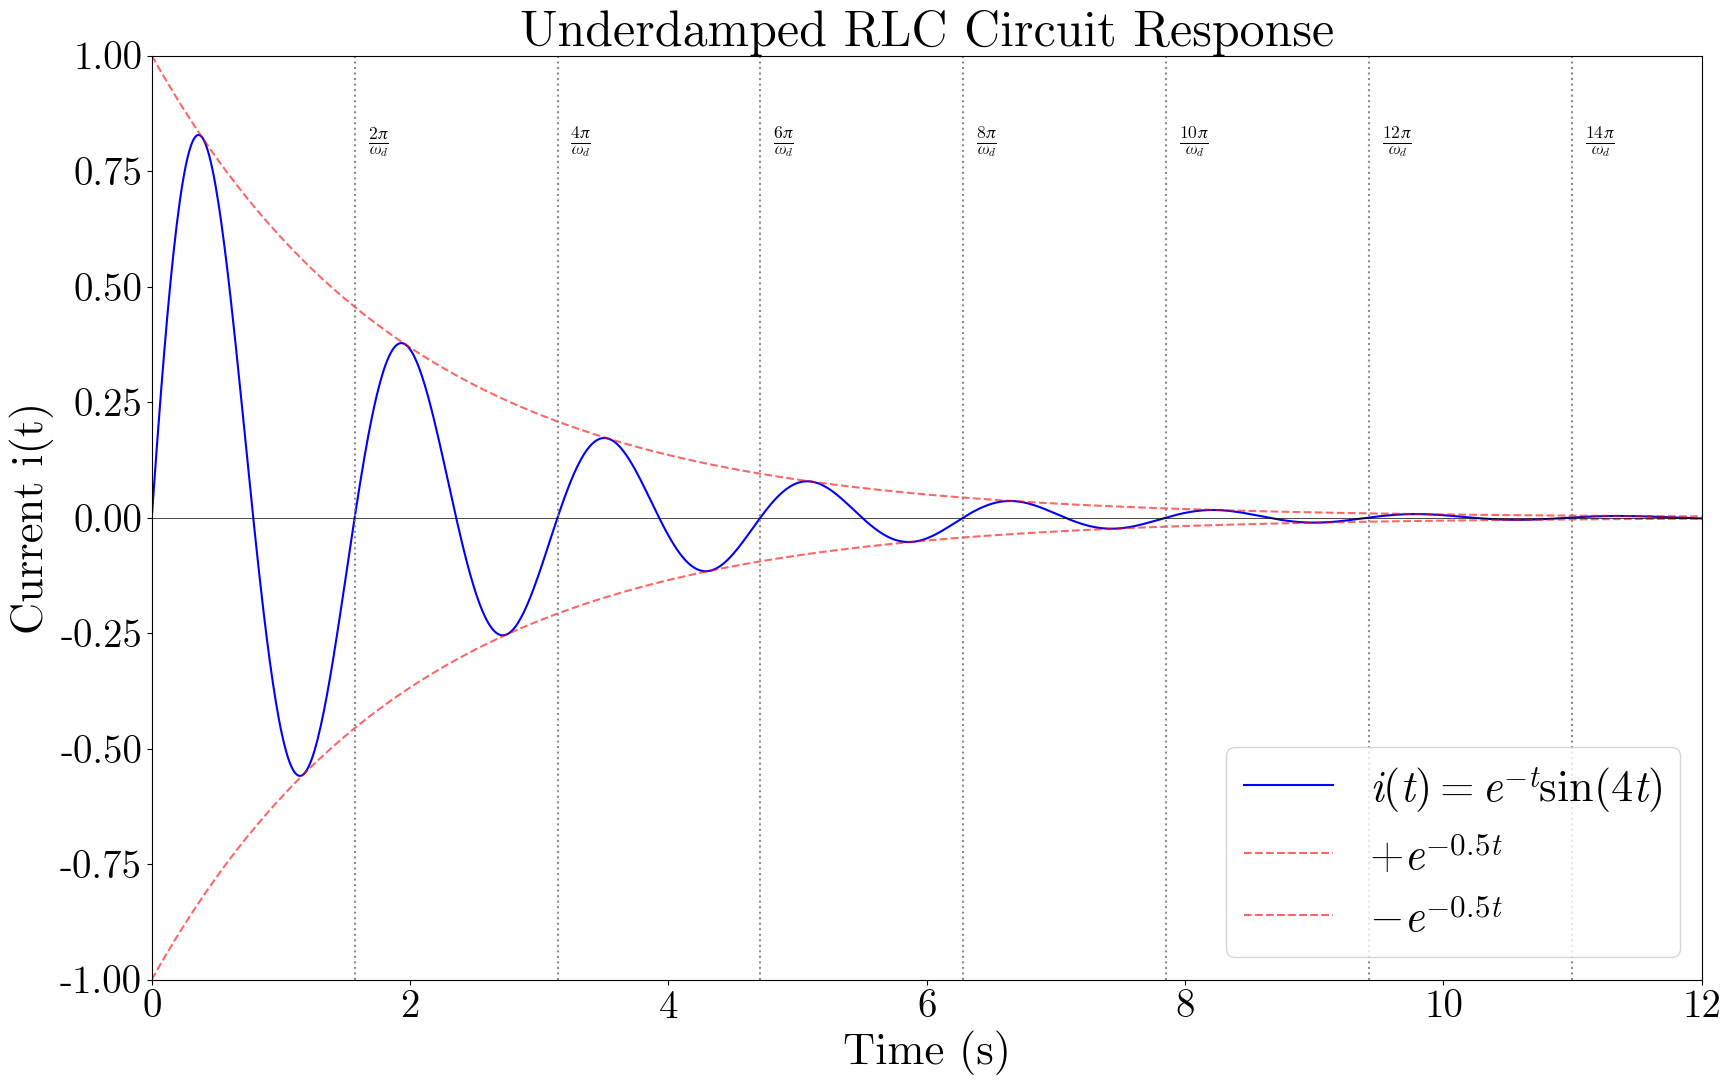

In [ ]:
# Parameters
alpha = 0.5
omega_d = 4

# Time range
t_vals = np.linspace(0, 12, 1000)

# Response and envelope
i_vals = np.exp(-alpha * t_vals) * np.sin(omega_d * t_vals)
envelope = np.exp(-alpha * t_vals)

# Plotting
plt.figure(figsize=(20, 12))
plt.plot(t_vals, i_vals, label=r'$i(t) = e^{-t} \sin('f'{omega_d}''t)$', color='blue')
plt.plot(t_vals, envelope, 'r--', label=r'$+e^{-'f'{alpha}''t}$', alpha=0.6)
plt.plot(t_vals, -envelope, 'r--', label=r'$-e^{-'f'{alpha}''t}$', alpha=0.6)
plt.title('Underdamped RLC Circuit Response')
plt.xlabel('Time (s)')
plt.ylabel('Current i(t)')
for n in range(2, 16, 2):
    x_val = n * np.pi / omega_d
    plt.axvline(x=x_val, color='gray', linestyle=':', alpha=0.9)
    plt.text(x_val + 0.1, 0.8, fr'$\frac{{{n}\pi}}{{\omega_d}}$', fontsize=18)
plt.axhline(0, color='black', lw=0.5, ls='-')
plt.xlim(0, 12)
plt.ylim(-1, 1)
plt.legend()
plt.grid(False)
plt.show()

## Part - C: Brain Teasers and Trivia



### 6. The Laplace Mystery



Given

$$
F(s) = \frac{1-e^{-3s}}{s}
$$

The exploration we made while solving the first question has borne fruit! We immediately identify that $\displaystyle \frac{e^{-3s}}{s}$ is the Laplace Transform of $u(t-3)$. Computing the Laplace Inverse of $F(s)$:

$$
\mathcal{L}^{-1}\{F(s)\} = \mathcal{L}^{-1}\{\frac{1}{s}\} - \mathcal{L}^{-1}\{\frac{e^{-3s}}{s}\} \hspace{1cm} \text{[Linearity Property]} \\
\\[1em]
\boxed{\mathcal{L}^{-1}\{F(s)\} = f(t) = 1 - u(t-3)}
$$

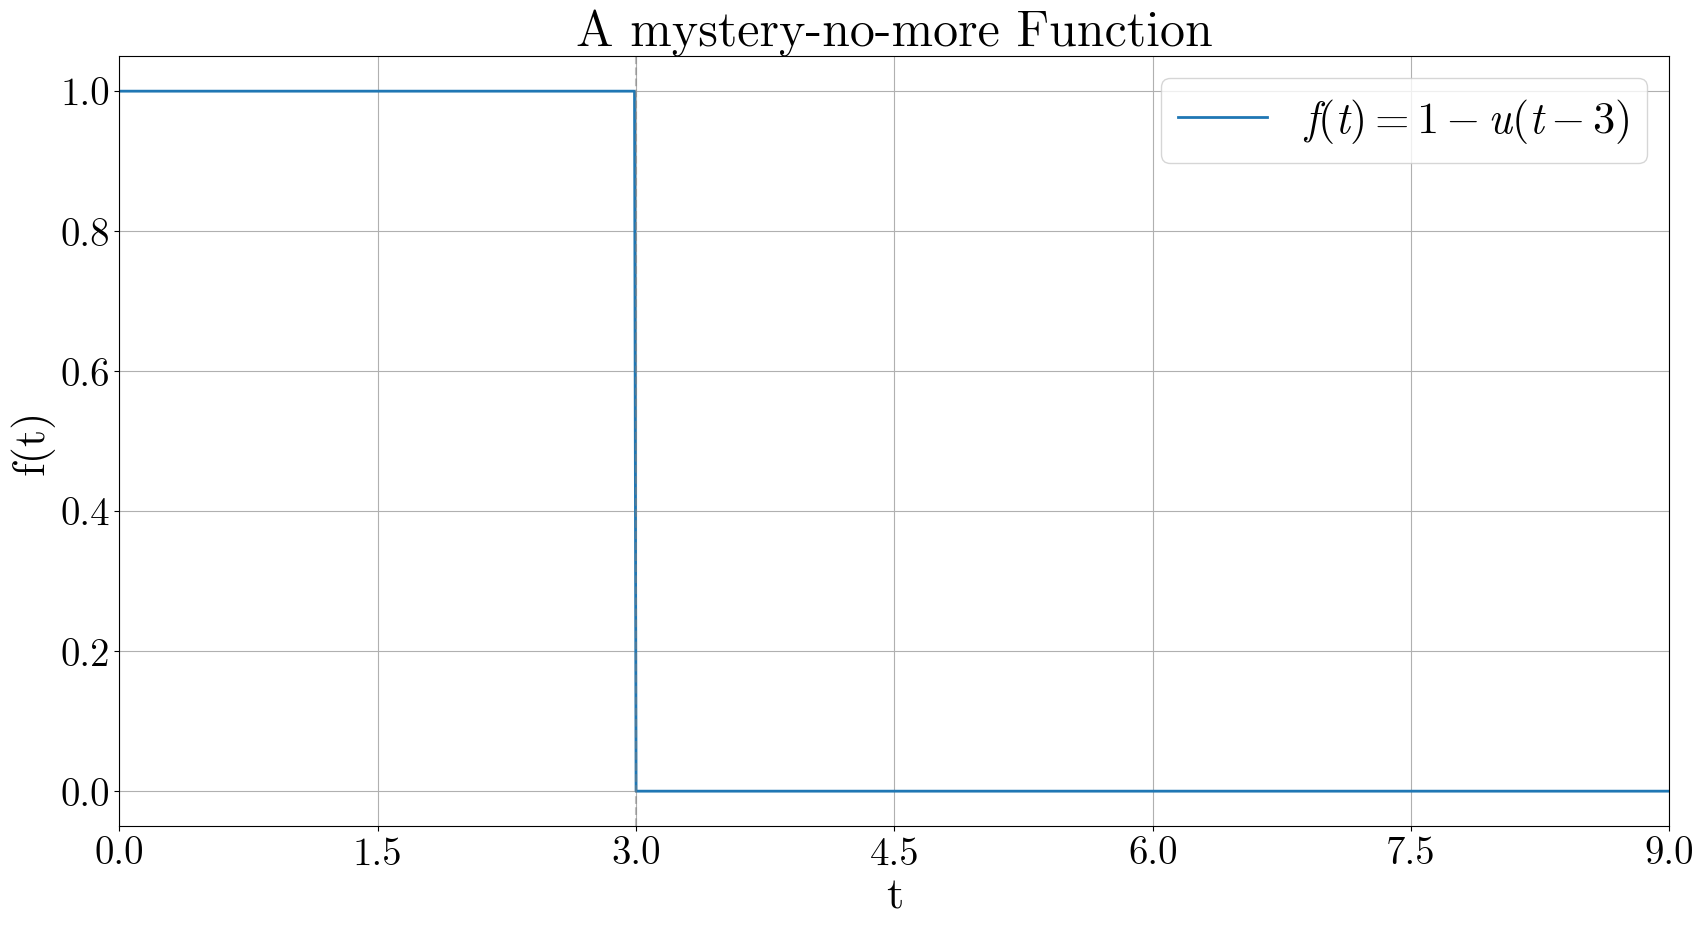

In [ ]:
t = np.linspace(0, 9, 1000)
f = 1 - np.heaviside(t - 3, 1)  # 1 in the argument means u(0) = 1

# Plot
plt.figure(figsize=(20, 10))
plt.plot(t, f, label=r'$f(t) = 1 - u(t - 3)$', linewidth=2)
plt.axvline(3, color='gray', linestyle='--', alpha=0.5)
plt.title("A mystery-no-more Function")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.xticks(np.arange(0, 10, 1.5))
plt.xlim(0, 9)
plt.grid(True)
plt.legend()
plt.show()


The function represents a signal that is ON for 3 seconds, then turns OFF forever.

> **Bonus:** Modify the equation if the time shift changes from 3s to 5s.

$$
f(t) = 1 - u(t-5)
$$

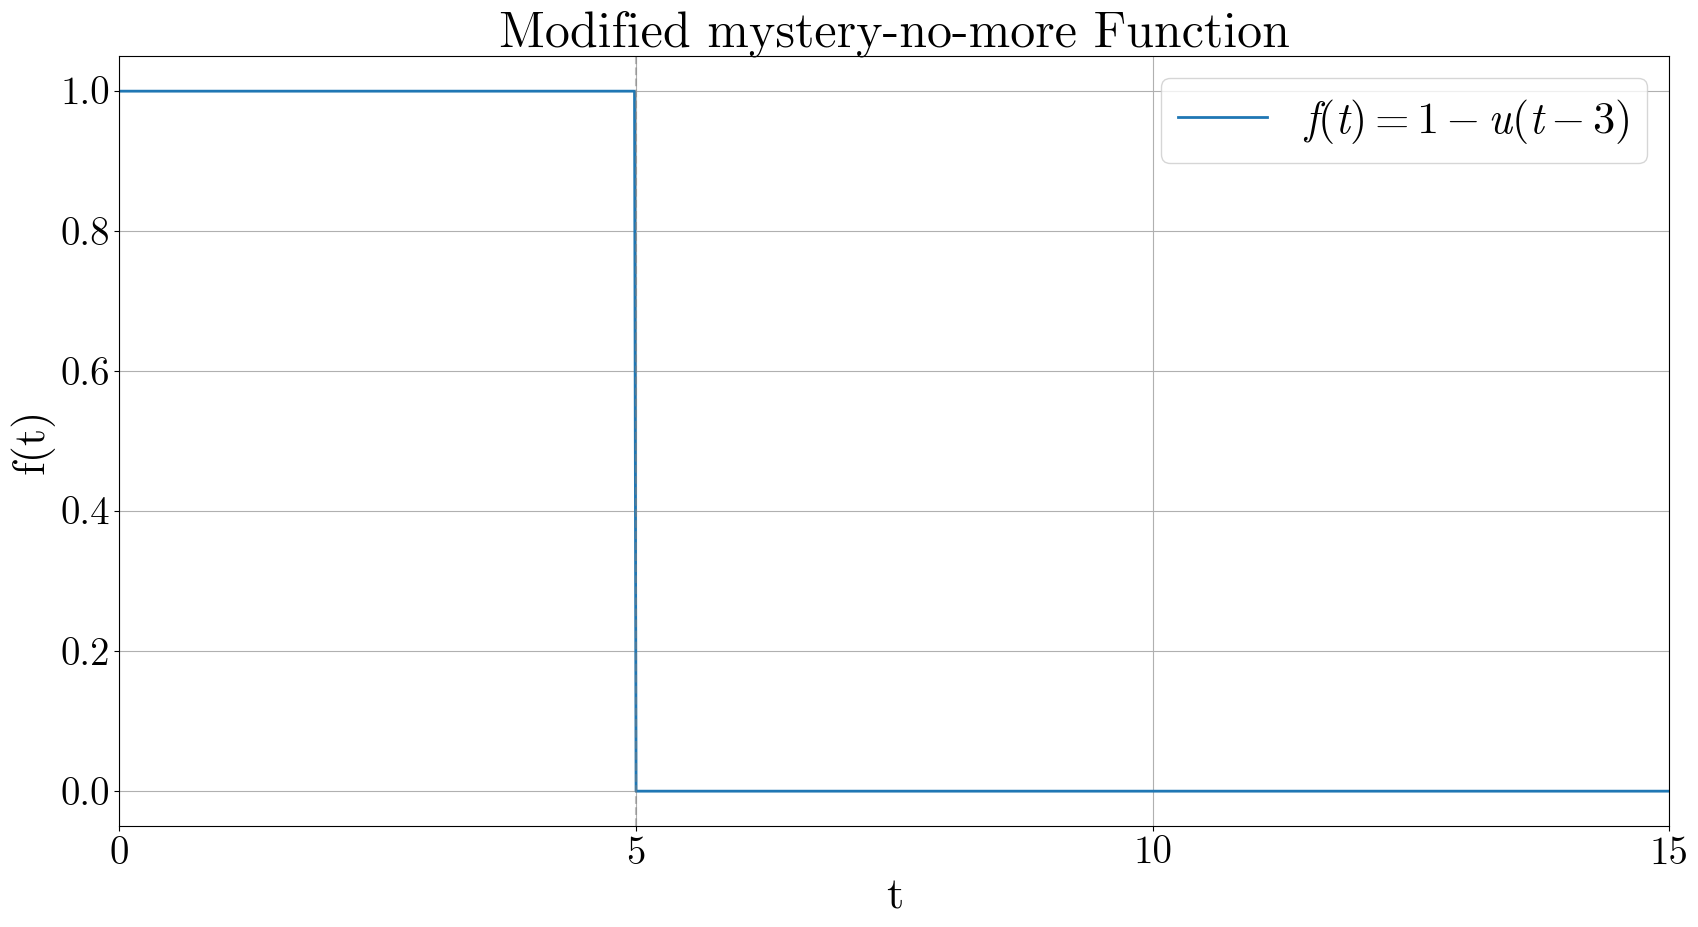

In [ ]:
t = np.linspace(0, 15, 1000)
f = 1 - np.heaviside(t - 5, 1)  # 1 in the argument means u(0) = 1

# Plot
plt.figure(figsize=(20, 10))
plt.plot(t, f, label=r'$f(t) = 1 - u(t - 3)$', linewidth=2)
plt.axvline(5, color='gray', linestyle='--', alpha=0.5)
plt.title("Modified mystery-no-more Function")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.xticks(np.arange(0, 16, 5))
plt.xlim(0, 15)
plt.grid(True)
plt.legend()
plt.show()


### 7. The "What If?" Thought Experiment



As we have seen already in Question 3, Laplace Transforms help a lot in simplifying our calculations involving **Transfer Functions**. The points where the denominator becomes 0 are called the **poles** and the points where the numerator becomes 0 are called the **zeroes** of the Transfer Function.

These can control the characteristics of the system that is being modelled using the Transfer Function. More specifically,
as $s$ approaches a zero, the numerator of the transfer function (and therefore the transfer function itself) approaches the value 0. When $s$ approaches a pole, the denominator of the transfer function approaches zero, and the value of the transfer function approaches infinity.

Let's say that we have a transfer function with 3 poles:

$$
H(s) = \frac{a}{(s - l)(s - m)(s - n)}
$$

The poles are located at $s = l, m, n$. Now, we can use partial fraction expansion to separate out the transfer function:

$$
H(s) = \frac{a}{(s - l)(s - m)(s - n)} = \frac{A}{s - l} + \frac{B}{s - m} + \frac{C}{s - n}
$$

Using the Inverse Laplace Transform on each of these component fractions, we get the following:

$$
h(t) = Ae^{lt}u(t) + Be^{mt}u(t) + Ce^{nt}u(t)
$$

But, since $s$ is a complex variable, $l, m, n$ can all potentially be complex numbers, with a real part ($\sigma$) and an imaginary part ($j\omega$). If we just look at the first term:

$$
Ae^{(\sigma + j\omega)t}u(t) = Ae^{\sigma t}e^{j\omega t}u(t)
$$

Using **Euler's Equation** on the imaginary exponent, we get:

$$
Ae^{\sigma t}[\cos(\omega t) + j\sin(\omega t)]u(t)
$$

If a complex pole is present it is always accompanied by another pole that is its complex conjugate. The imaginary parts of their time domain representations thus cancel and we are left with 2 of the same real parts. Assuming that the complex conjugate pole of the first term is present, we can take 2 times the real part of this equation and we are left with our final result:

$$
2Ae^{\sigma t} \cos(\omega t)u(t)
$$

We can see from this equation that every pole will have an exponential part, and a sinusoidal part to its response. We can also go about constructing some rules:

1. If $\sigma = 0$, the response of the pole is a perfect sinusoidal (an oscillator).
2. If $\omega = 0$, the response of the pole is a perfect exponential.
3. If $\sigma < 0$, the exponential part of the response will decay towards zero.
4. If $\sigma > 0$, the exponential part of the response will rise towards infinity.

From the last two rules, we can see that all poles of the system must have negative real parts, and therefore they must all have the form $(s + l)$ for the system to be stable (not output an infinity response).

The locations of the poles, and the values of the real and imaginary parts of the pole determine the response of the system. Real parts correspond to exponentials, and imaginary parts correspond to sinusoidal values. **Addition of poles** to the transfer function has the effect of pulling the graph to the right, making the system less stable. **Addition of zeros** to the transfer function has the effect of pulling the graph to the left, making the system more stable.

> **Bonus:** Research and find a real-life engineering application where Laplace Transforms were crucial.

**Programmable Logic Controllers (PLCs)** in industrial automation often rely on **step-based control sequences**. Each operational phase (e.g., motor on/off, valve open/close) is modeled using time-triggered step functions.

Engineers use Laplace Transforms of Heaviside-based inputs to design and simulate:

- Motor startup sequences
- Controlled ramp inputs for conveyor belts
- On-delay and off-delay timers

This kind of modeling is crucial in industries like automated manufacturing, elevators, and process control systems, where time-accurate switching governs the behavior of machines and safety systems.

## References



- https://en.wikipedia.org/wiki/Laplace_transform
- https://en.wikipedia.org/wiki/Heaviside_step_function
- https://en.wikipedia.org/wiki/Dirac_delta_function
- https://www.youtube.com/watch?v=spUNpyF58BY
- Fundamentals of electric circuits / Charles K. Alexander, Matthew N. O. Sadiku. — 4th ed
- https://www.analog.com/media/en/technical-documentation/dsp-book/dsp_book_Ch32.pdf
- https://en.wikipedia.org/wiki/Linear_time-invariant_system
- https://www.desmos.com/calculator/si83byyyrx
- https://en.wikipedia.org/wiki/Mollifier
- https://en.wikibooks.org/wiki/Control_Systems/Poles_and_Zeros


An interactive version of this document is available on [Colab](https://colab.research.google.com/github/pseudoforceyt/projectTitin/blob/main/ltassignment.ipynb) at [https://colab.research.google.com/github/pseudoforceyt/projectTitin/blob/main/ltassignment.ipynb](https://colab.research.google.com/github/pseudoforceyt/projectTitin/blob/main/ltassignment.ipynb)

Some equations fail to format correctly but you can play around with the code to modify the graphs of the functions.

Generative AI has not been used in the formulation of this document.